### Imports and Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import missingno as msno 
from sklearn import clone
from copy import deepcopy
import scipy.stats as stats
from itertools import combinations
import math

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils import check_array
from scikeras.wrappers import KerasRegressor 
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.feature_selection import SelectKBest, RFE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV, RandomizedSearchCV, KFold
from scipy.stats import uniform, randint
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score,KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error,root_mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.linear_model import HuberRegressor

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier,  GradientBoostingRegressor, StackingRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor,export_text
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans

import tensorflow as tf
from tensorflow import keras
from keras import layers, Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

In [4]:
insurance_data = pd.read_csv('insurance_claim_data.csv')

### Exploratory Data Analysis 

#### General Data Analysis

In [5]:
insurance_data.shape

(5000, 36)

In [6]:
insurance_data.head()

,SettlementValue,AccidentType,Injury_Prognosis,SpecialHealthExpenses,SpecialReduction,SpecialOverage,GeneralRest,SpecialAdditionalInjury,SpecialEarningsLoss,SpecialUsageLoss,...,Accident Date,Claim Date,Vehicle Age,Driver Age,Number of Passengers,Accident Description,Injury Description,Police Report Filed,Witness Present,Gender
0,520.0,Rear end,E. 5 months,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2023-11-10 11:22:24.508901,2024-06-11 11:22:24.508901,13.0,33.0,4.0,Side collision at an intersection.,Whiplash and minor bruises.,Yes,Yes,Male
1,870.0,Rear end,B. 2 months,0.0,0.0,0.0,520.0,0.0,0.0,90.0,...,2023-06-25 00:55:01.140228,2024-01-09 00:55:01.140228,4.0,45.0,2.0,Side collision at an intersection.,Minor cuts and scrapes.,Yes,Yes,Female
2,2140.0,Other side pulled out of side road,G. 7 months,0.0,0.0,0.0,1400.0,0.0,0.0,0.0,...,2020-02-23 17:43:47.805561,2020-03-01 17:43:47.805561,9.0,45.0,4.0,Lost control on a snowy road.,Whiplash and minor bruises.,Yes,No,Female
3,520.0,Rear end - Clt pushed into next vehicle,D. 4 months,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2021-10-02 04:36:32.118423,2021-10-13 04:36:32.118423,5.0,62.0,1.0,Side collision at an intersection.,Minor cuts and scrapes.,Yes,Yes,Female
4,260.0,Rear end,C. 3 months,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2023-04-02 05:13:07.117423,2023-04-14 05:13:07.117423,9.0,78.0,1.0,Lost control on a snowy road.,Concussion and bruised ribs.,Yes,Yes,Other


In [7]:
insurance_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   SettlementValue             4894 non-null   float64
 1   AccidentType                4878 non-null   object 
 2   Injury_Prognosis            4844 non-null   object 
 3   SpecialHealthExpenses       4870 non-null   float64
 4   SpecialReduction            4879 non-null   float64
 5   SpecialOverage              4883 non-null   float64
 6   GeneralRest                 4872 non-null   float64
 7   SpecialAdditionalInjury     4866 non-null   float64
 8   SpecialEarningsLoss         4872 non-null   float64
 9   SpecialUsageLoss            4870 non-null   float64
 10  SpecialMedications          4870 non-null   float64
 11  SpecialAssetDamage          4889 non-null   float64
 12  SpecialRehabilitation       4884 non-null   float64
 13  SpecialFixes                4879 

In [8]:
insurance_data.describe()

,SettlementValue,SpecialHealthExpenses,SpecialReduction,SpecialOverage,GeneralRest,SpecialAdditionalInjury,SpecialEarningsLoss,SpecialUsageLoss,SpecialMedications,SpecialAssetDamage,...,SpecialFixes,GeneralFixed,GeneralUplift,SpecialLoanerVehicle,SpecialTripCosts,SpecialJourneyExpenses,SpecialTherapy,Vehicle Age,Driver Age,Number of Passengers
count,4894.000000,4870.000000,4879.0,4883.000000,4872.000000,4866.000000,4872.000000,4870.000000,4870.000000,4889.000000,...,4879.000000,4879.000000,4863.000000,4861.000000,4885.000000,4853.000000,4868.000000,4874.000000,4871.000000,4878.000000
mean,1218.010685,3.611704,0.0,13.363580,463.305386,0.283580,52.191115,9.108830,0.109698,33.460761,...,3.942209,687.509736,10.407465,7.719720,1.959881,11.639120,183.600286,9.508617,48.789160,2.482370
std,858.866309,85.047845,0.0,84.223612,766.187669,12.988075,392.909130,65.505181,1.389916,282.692529,...,116.335053,399.361279,50.165743,141.155658,13.117419,49.086924,223.885780,5.727625,17.819725,1.109911
min,240.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,240.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,1.000000
25%,669.140000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,495.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,33.000000,1.000000
50%,988.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,520.000000,0.000000,0.000000,0.000000,0.000000,50.000000,10.000000,49.000000,2.000000
75%,1510.000000,0.000000,0.0,0.000000,906.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,895.000000,0.000000,0.000000,0.000000,0.000000,350.000000,14.000000,64.000000,3.000000
max,7862.900000,3024.000000,0.0,1250.000000,3912.640000,889.000000,7735.580000,1050.000000,30.250000,6070.000000,...,4000.000000,4345.000000,1430.000000,4408.160000,254.200000,880.000000,1225.000000,19.000000,79.000000,4.000000


In [9]:
missing_counts = insurance_data.isnull().sum(axis=1)
# Count rows with at least 1, 2, and 3 missing values
none_missing = (missing_counts == 0).sum()
at_least_1_missing = (missing_counts == 1).sum()
at_least_2_missing = (missing_counts == 2).sum()
at_least_3_missing = (missing_counts == 3).sum()
at_least_4_missing = (missing_counts == 4).sum()
at_least_5_missing = (missing_counts == 5).sum()
at_least_6_missing = (missing_counts == 6).sum()
## Print the Count
print(f"Number of rows with no missing features: {none_missing}")
print(f"Number of rows with 1 missing feature: {at_least_1_missing}")
print(f"Number of rows with 2 missing features: {at_least_2_missing}")
print(f"Number of rows with 3 missing features: {at_least_3_missing}")
print(f"Number of rows with 4 missing features: {at_least_4_missing}")
print(f"Number of rows with 5 missing features: {at_least_5_missing}")
print(f"Number of rows with 6 missing features: {at_least_6_missing}")

Number of rows with no missing features: 3545
Number of rows with 1 missing feature: 305
Number of rows with 2 missing features: 328
Number of rows with 3 missing features: 324
Number of rows with 4 missing features: 311
Number of rows with 5 missing features: 187
Number of rows with 6 missing features: 0


<Axes: >

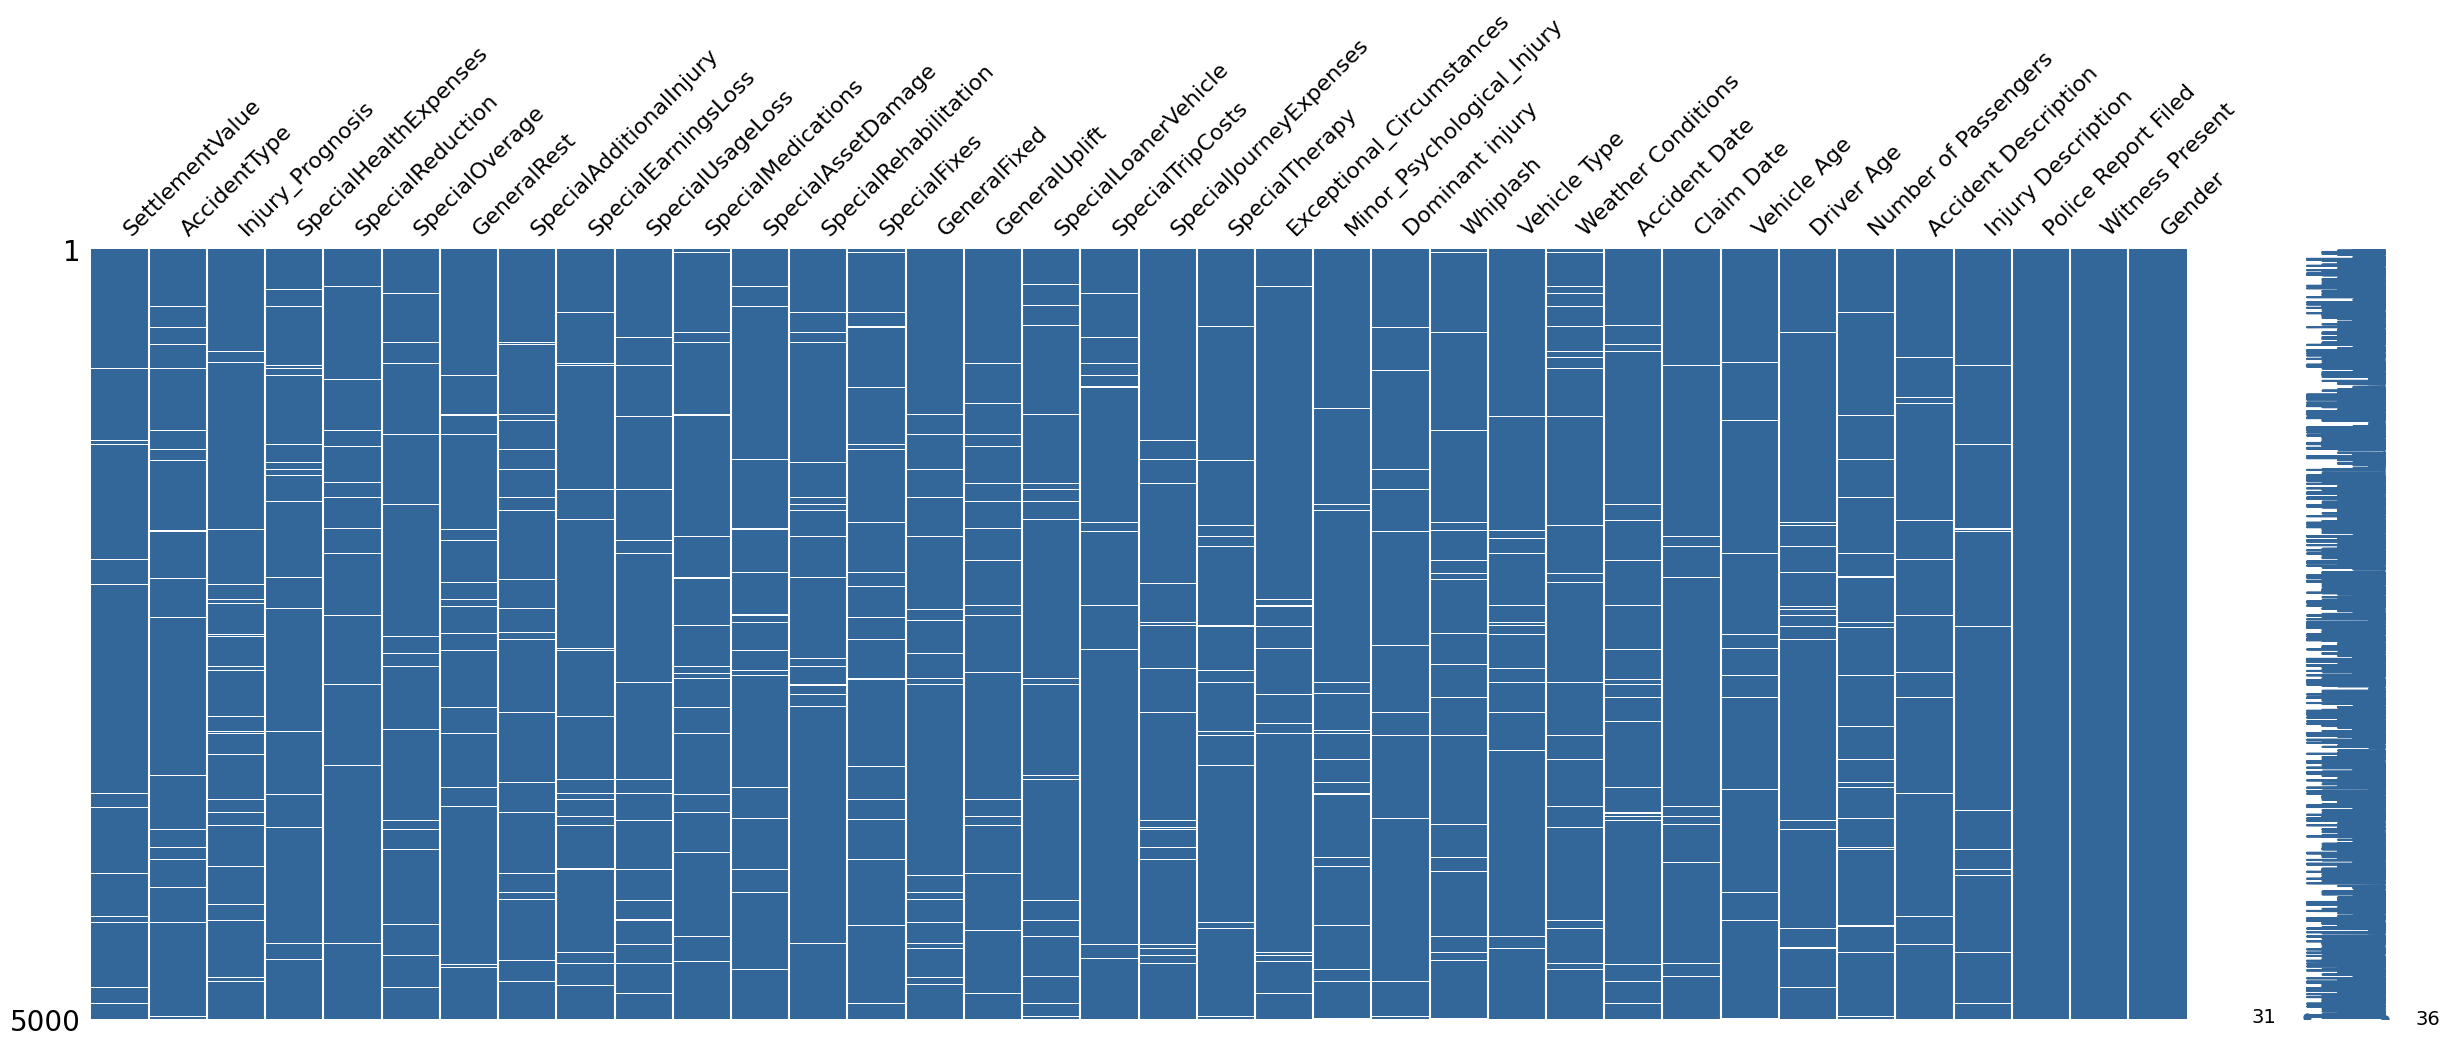

In [10]:
msno.matrix(insurance_data, figsize=(30, 10), color=(0.2, 0.4, 0.6))

<Axes: >

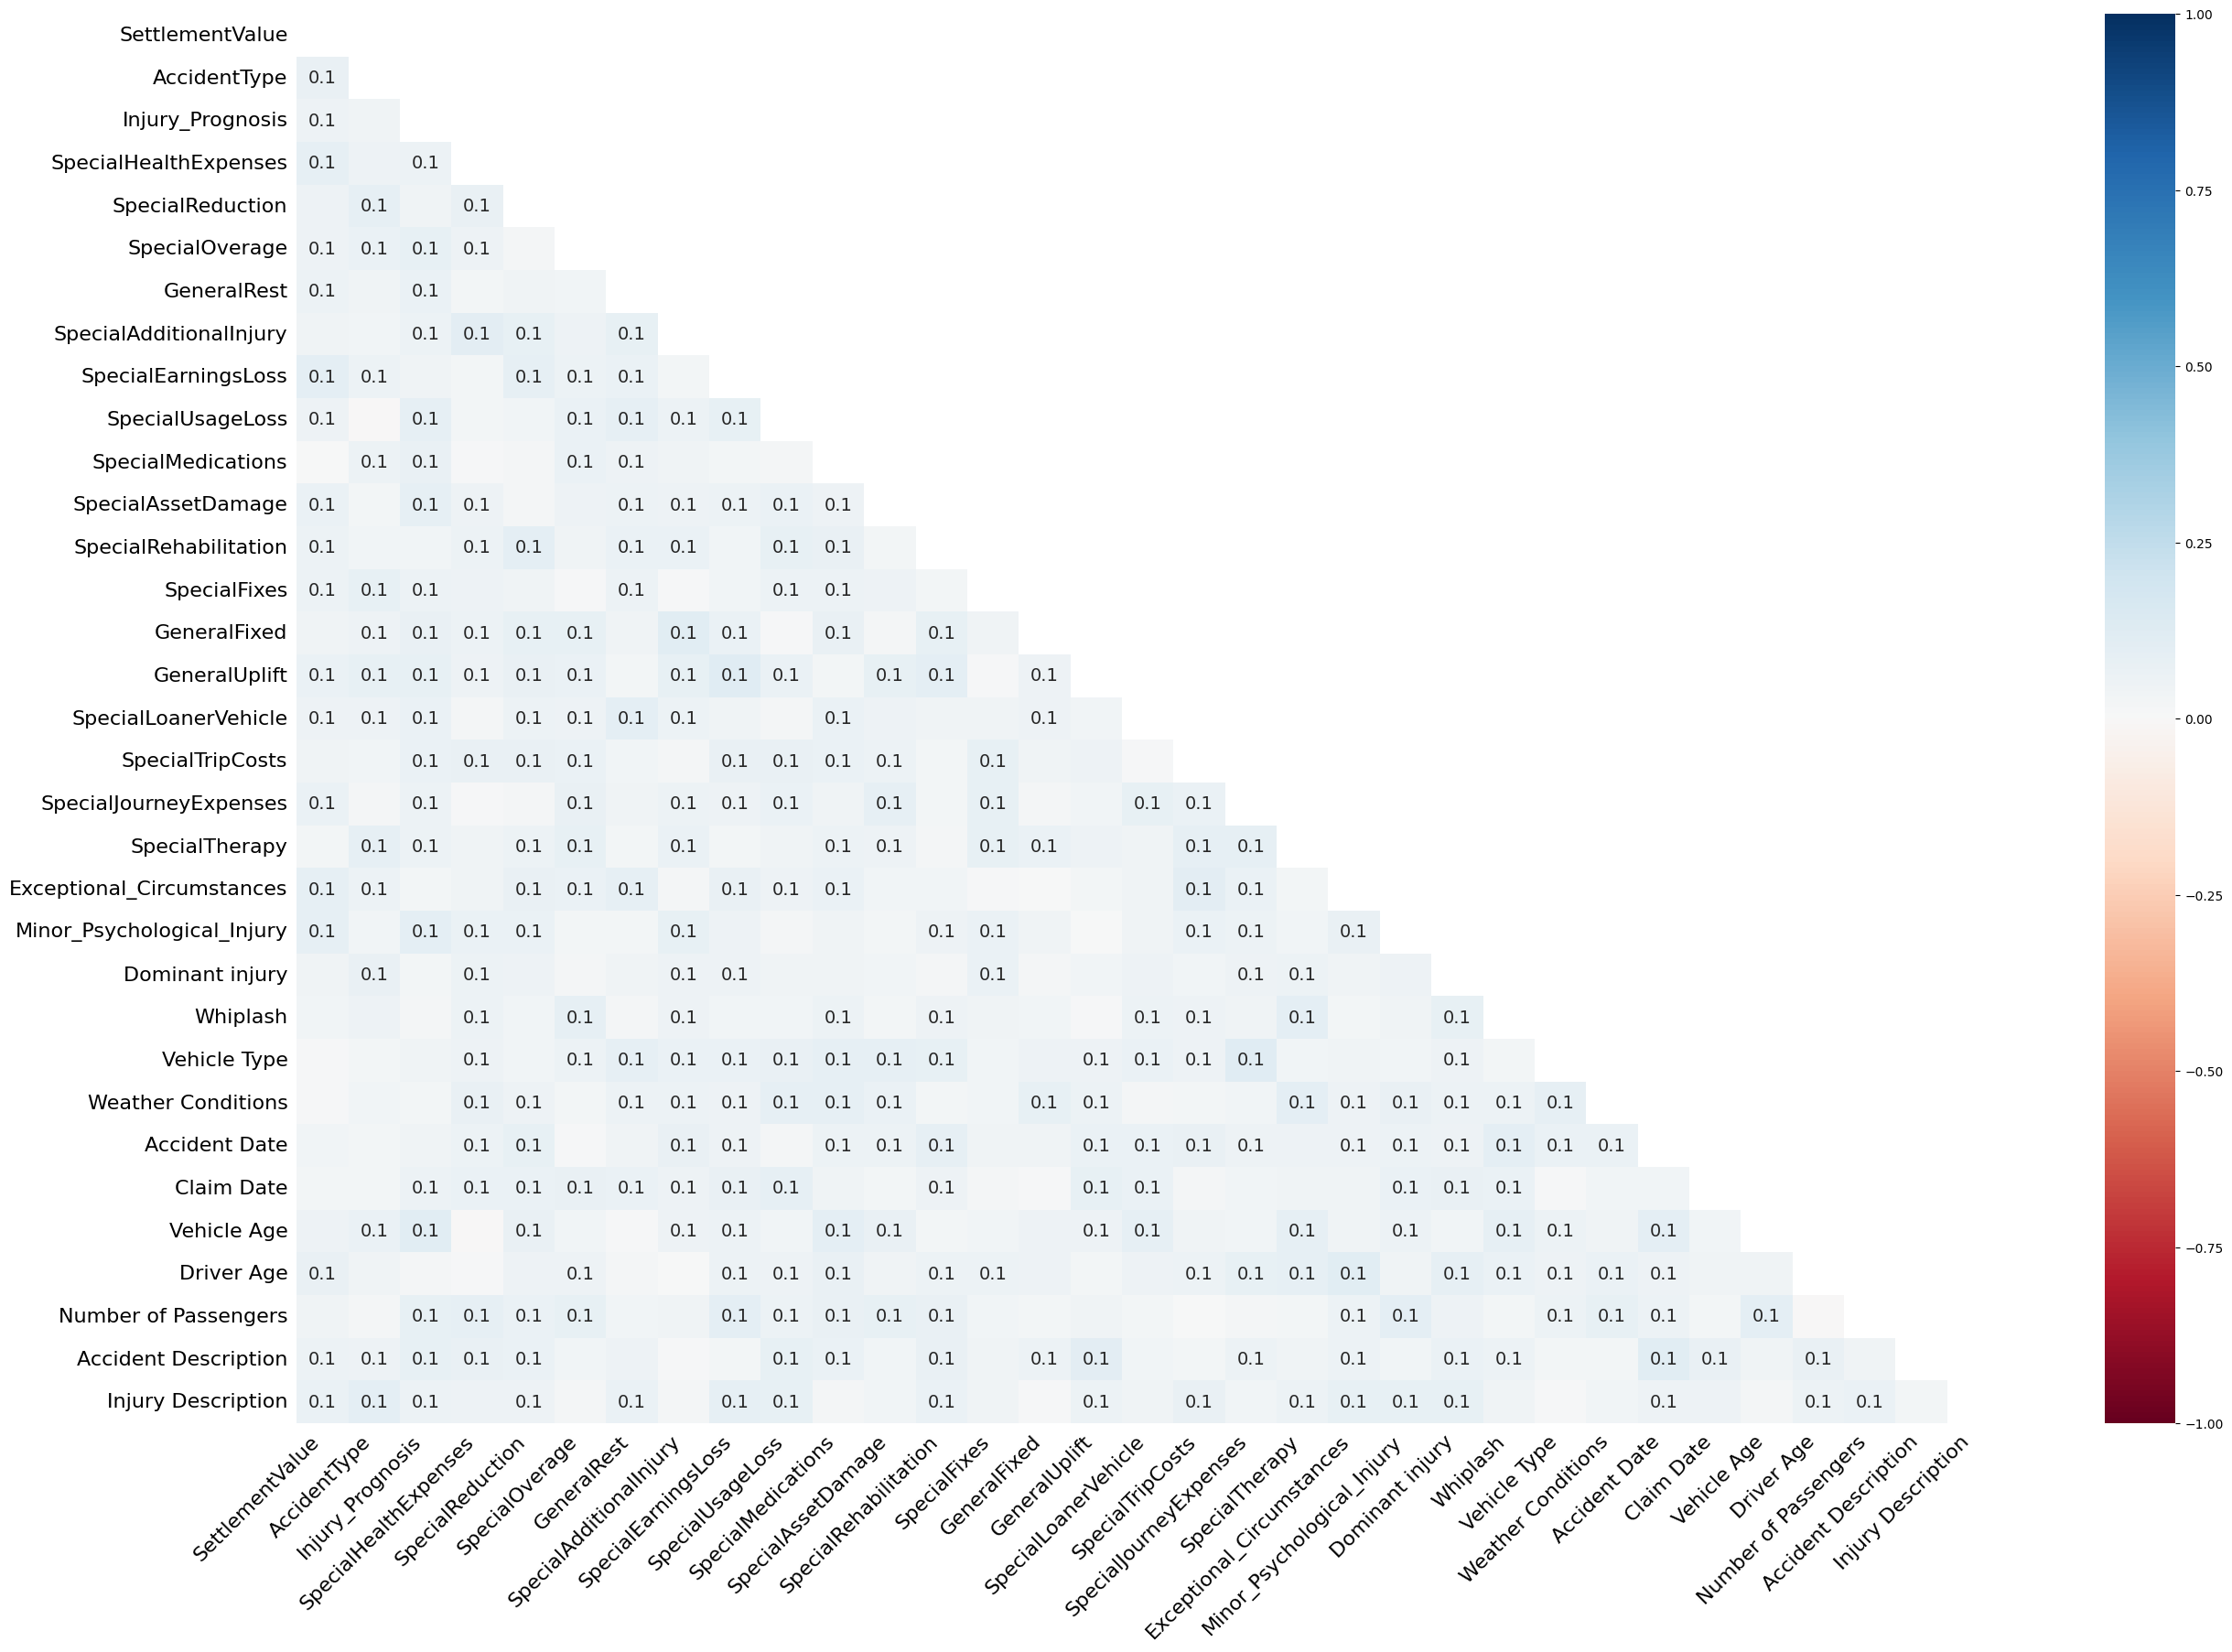

In [11]:
msno.heatmap(insurance_data, figsize=(30,20))

In [12]:
insurance_data.nunique()

SettlementValue               1022
AccidentType                    18
Injury_Prognosis                21
SpecialHealthExpenses            7
SpecialReduction                 1
SpecialOverage                  23
GeneralRest                    266
SpecialAdditionalInjury          5
SpecialEarningsLoss            108
SpecialUsageLoss                36
SpecialMedications              10
SpecialAssetDamage             156
SpecialRehabilitation            3
SpecialFixes                     5
GeneralFixed                    14
GeneralUplift                   19
SpecialLoanerVehicle            20
SpecialTripCosts                77
SpecialJourneyExpenses         269
SpecialTherapy                 300
Exceptional_Circumstances        2
Minor_Psychological_Injury       2
Dominant injury                  4
Whiplash                         2
Vehicle Type                     3
Weather Conditions               3
Accident Date                 3146
Claim Date                    4882
Vehicle Age         

In [13]:
insurance_data.isnull().sum()

SettlementValue               106
AccidentType                  122
Injury_Prognosis              156
SpecialHealthExpenses         130
SpecialReduction              121
SpecialOverage                117
GeneralRest                   128
SpecialAdditionalInjury       134
SpecialEarningsLoss           128
SpecialUsageLoss              130
SpecialMedications            130
SpecialAssetDamage            111
SpecialRehabilitation         116
SpecialFixes                  121
GeneralFixed                  121
GeneralUplift                 137
SpecialLoanerVehicle          139
SpecialTripCosts              115
SpecialJourneyExpenses        147
SpecialTherapy                132
Exceptional_Circumstances     109
Minor_Psychological_Injury    119
Dominant injury               110
Whiplash                      130
Vehicle Type                  126
Weather Conditions            114
Accident Date                 138
Claim Date                    109
Vehicle Age                   126
Driver Age    

In [14]:
def label_injury_combo(row):
    if row['Minor_Psychological_Injury'] == 'Yes' and row['Whiplash'] == 'Yes':
        return 'Both'
    elif row['Minor_Psychological_Injury'] == 'Yes':
        return 'Psych Only'
    elif row['Whiplash'] == 'Yes':
        return 'Whiplash Only'
    else:
        return 'None'

insurance_data['InjuryCombo'] = insurance_data.apply(label_injury_combo, axis=1)
insurance_data['InjuryCombo'].value_counts()

InjuryCombo
Psych Only       1870
Both             1796
None              687
Whiplash Only     647
Name: count, dtype: int64

<Axes: xlabel='InjuryCombo', ylabel='SettlementValue'>

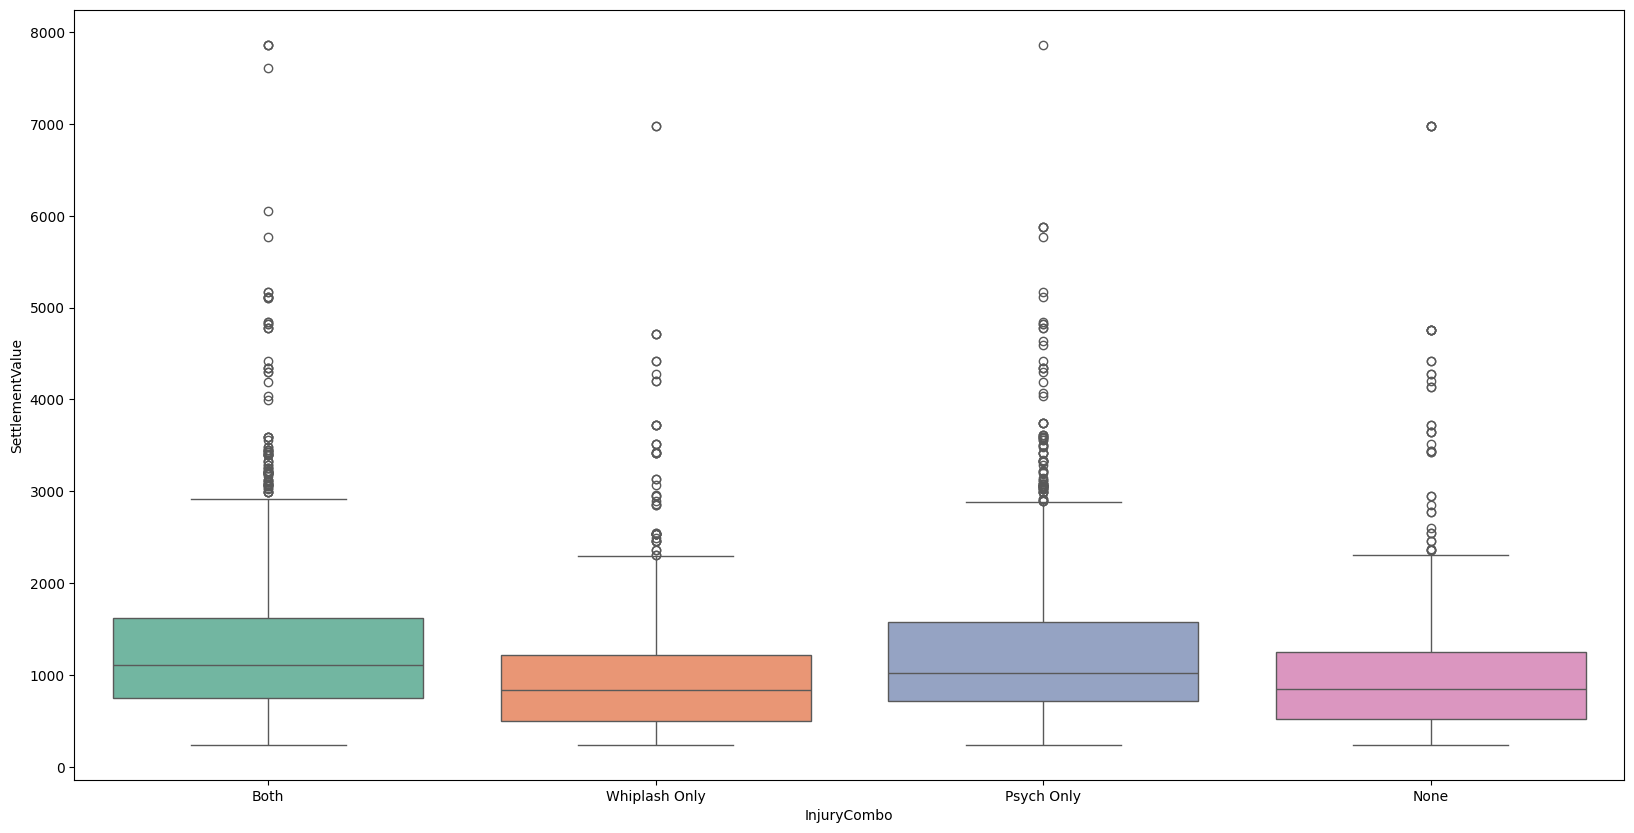

In [15]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=insurance_data, x='InjuryCombo', y='SettlementValue',hue='InjuryCombo', palette='Set2')

In [16]:
insurance_data.groupby('InjuryCombo')['SettlementValue'].describe()


,count,mean,std,min,25%,50%,75%,max
InjuryCombo,,,,,,,,
Both,1756.0,1304.540000,871.947145,240.0,753.500,1107.5,1622.2400,7862.90
None,667.0,1070.993478,896.481758,240.0,520.000,851.0,1249.4250,6976.96
Psych Only,1834.0,1254.211478,820.224815,240.0,713.665,1021.0,1579.9425,7862.90
Whiplash Only,637.0,1029.192386,844.797096,240.0,495.000,840.0,1216.0000,6976.96


In [17]:
# create separate dataframes for variables based on different data types
numerical_data = insurance_data.select_dtypes(include=['float64'])
categorical_data = insurance_data.select_dtypes(include=['object'])


In [18]:
categorical_data.describe()

,AccidentType,Injury_Prognosis,Exceptional_Circumstances,Minor_Psychological_Injury,Dominant injury,Whiplash,Vehicle Type,Weather Conditions,Accident Date,Claim Date,Accident Description,Injury Description,Police Report Filed,Witness Present,Gender,InjuryCombo
count,4878,4844,4891,4881,4890,4870,4874,4886,4862,4891,4880,4881,5000,5000,5000,5000
unique,18,21,2,2,4,2,3,3,3146,4882,5,5,2,2,3,4
top,Rear end,F. 6 months,No,Yes,Legs,Yes,Car,Rainy,2023-06-15 02:35:50.350070,2020-12-29 04:59:17.511502,Hit a deer on the highway.,Fractured arm and leg.,Yes,No,Male,Psych Only
freq,2564,1100,4583,3666,1265,2443,1664,1650,5,2,1053,1067,2525,2558,1684,1870


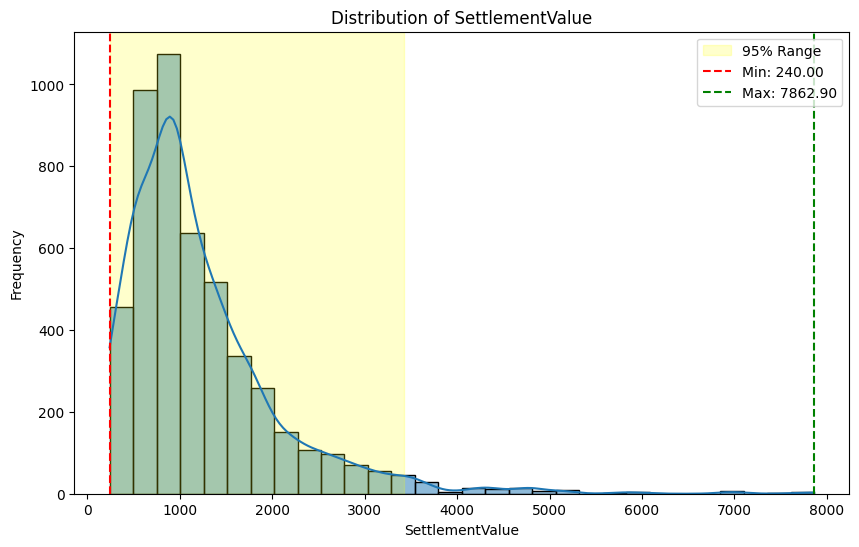

In [19]:
## Showing Distribution of SettlementValue (Target Variable)
## We also want to know what is the 95% boundary for the SettlementValue 
plt.figure(figsize=(10, 6))
sns.histplot(numerical_data['SettlementValue'].dropna(), bins=30, kde=True)
plt.title('Distribution of SettlementValue')
plt.xlabel('SettlementValue')
# Calculate 2.5th and 97.5th percentiles for 95% boundary
lower, upper = np.percentile(numerical_data['SettlementValue'].dropna(), [2.5, 97.5])
plt.axvspan(lower, upper, color='yellow', alpha=0.2, label='95% Range')
plt.ylabel('Frequency')
plt.axvline(numerical_data['SettlementValue'].min(), color='red', linestyle='--', label=f"Min: {numerical_data['SettlementValue'].min():.2f}")
plt.axvline(numerical_data['SettlementValue'].max(), color='green', linestyle='--', label=f"Max: {numerical_data['SettlementValue'].max():.2f}")
plt.legend()
plt.show()

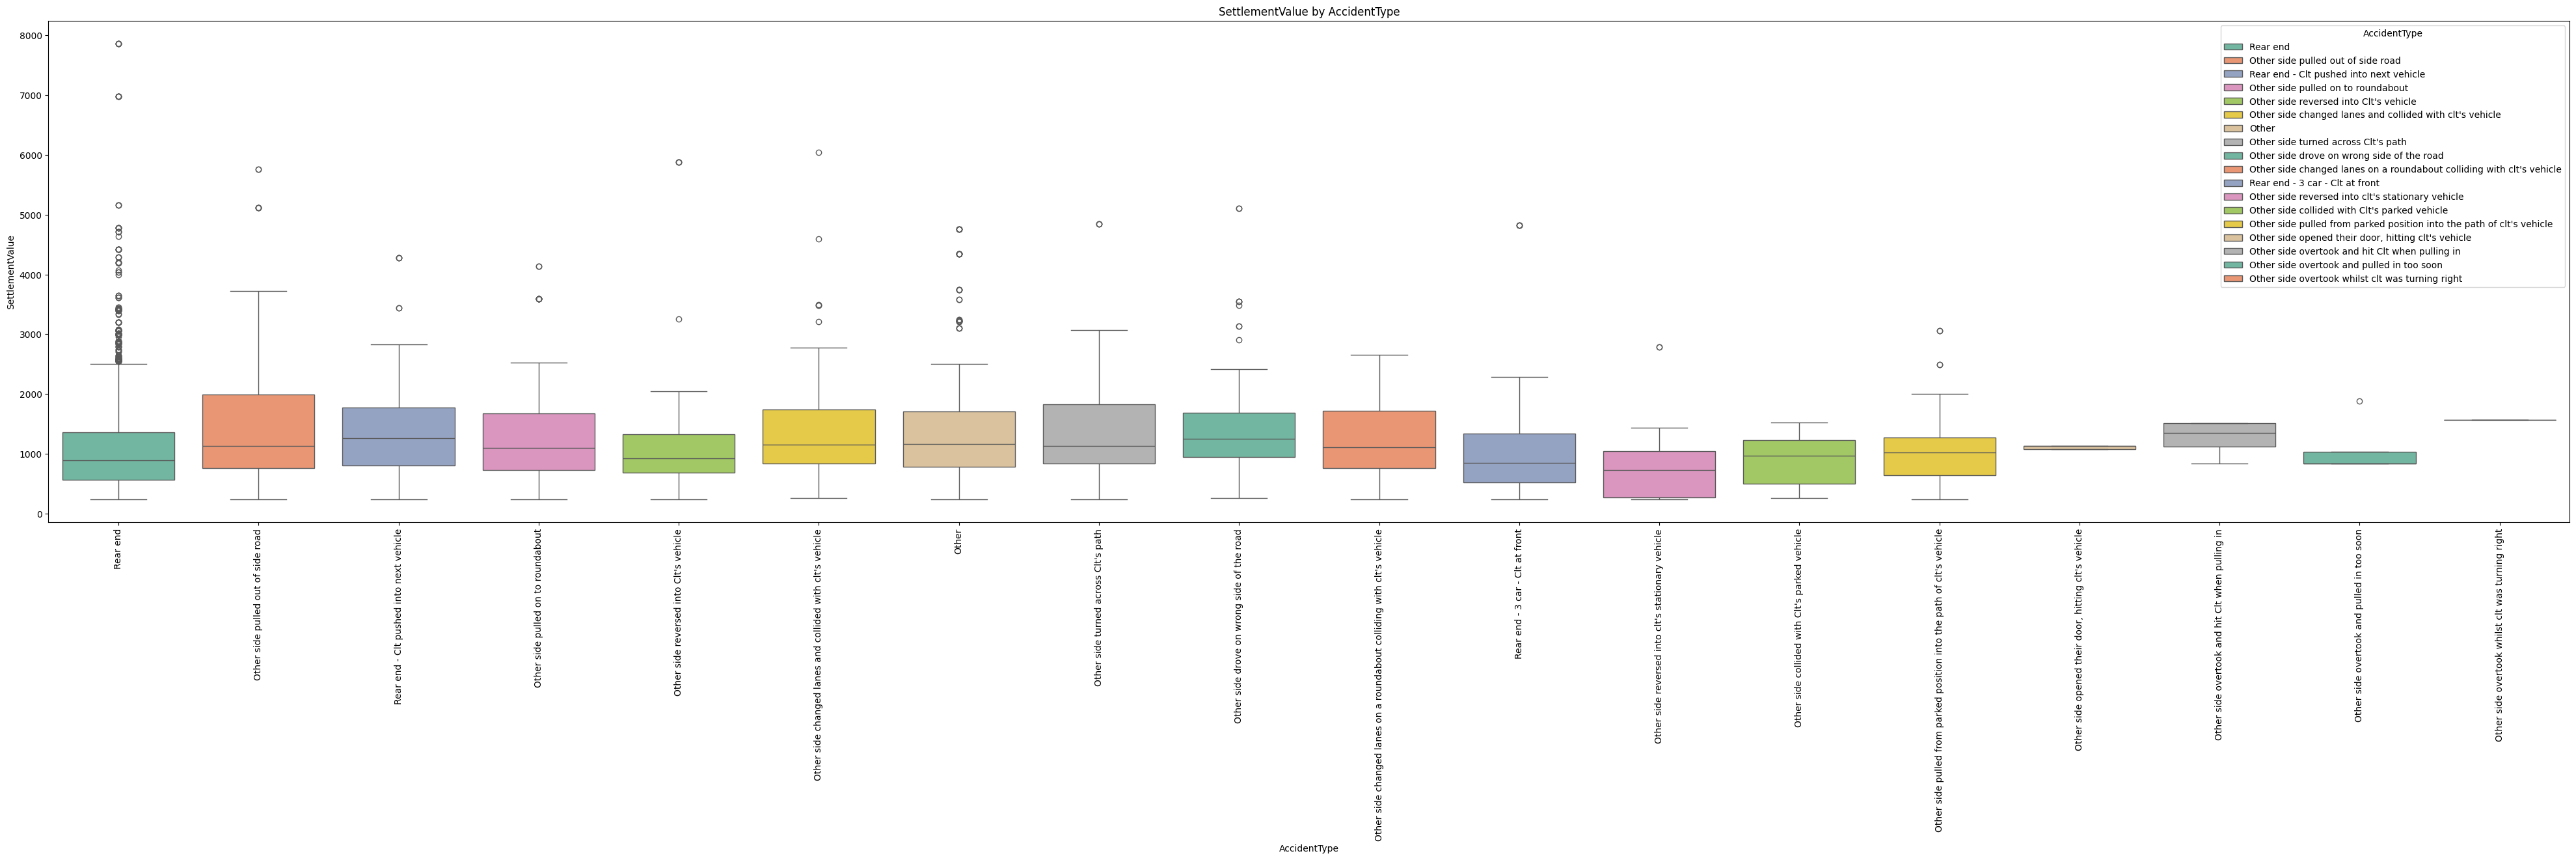

In [20]:
plt.figure(figsize=(50, 10))
sns.boxplot(data=insurance_data, x='AccidentType', y='SettlementValue', hue='AccidentType', palette='Set2')
plt.title('SettlementValue by AccidentType')
plt.xticks(rotation=90)
plt.show()

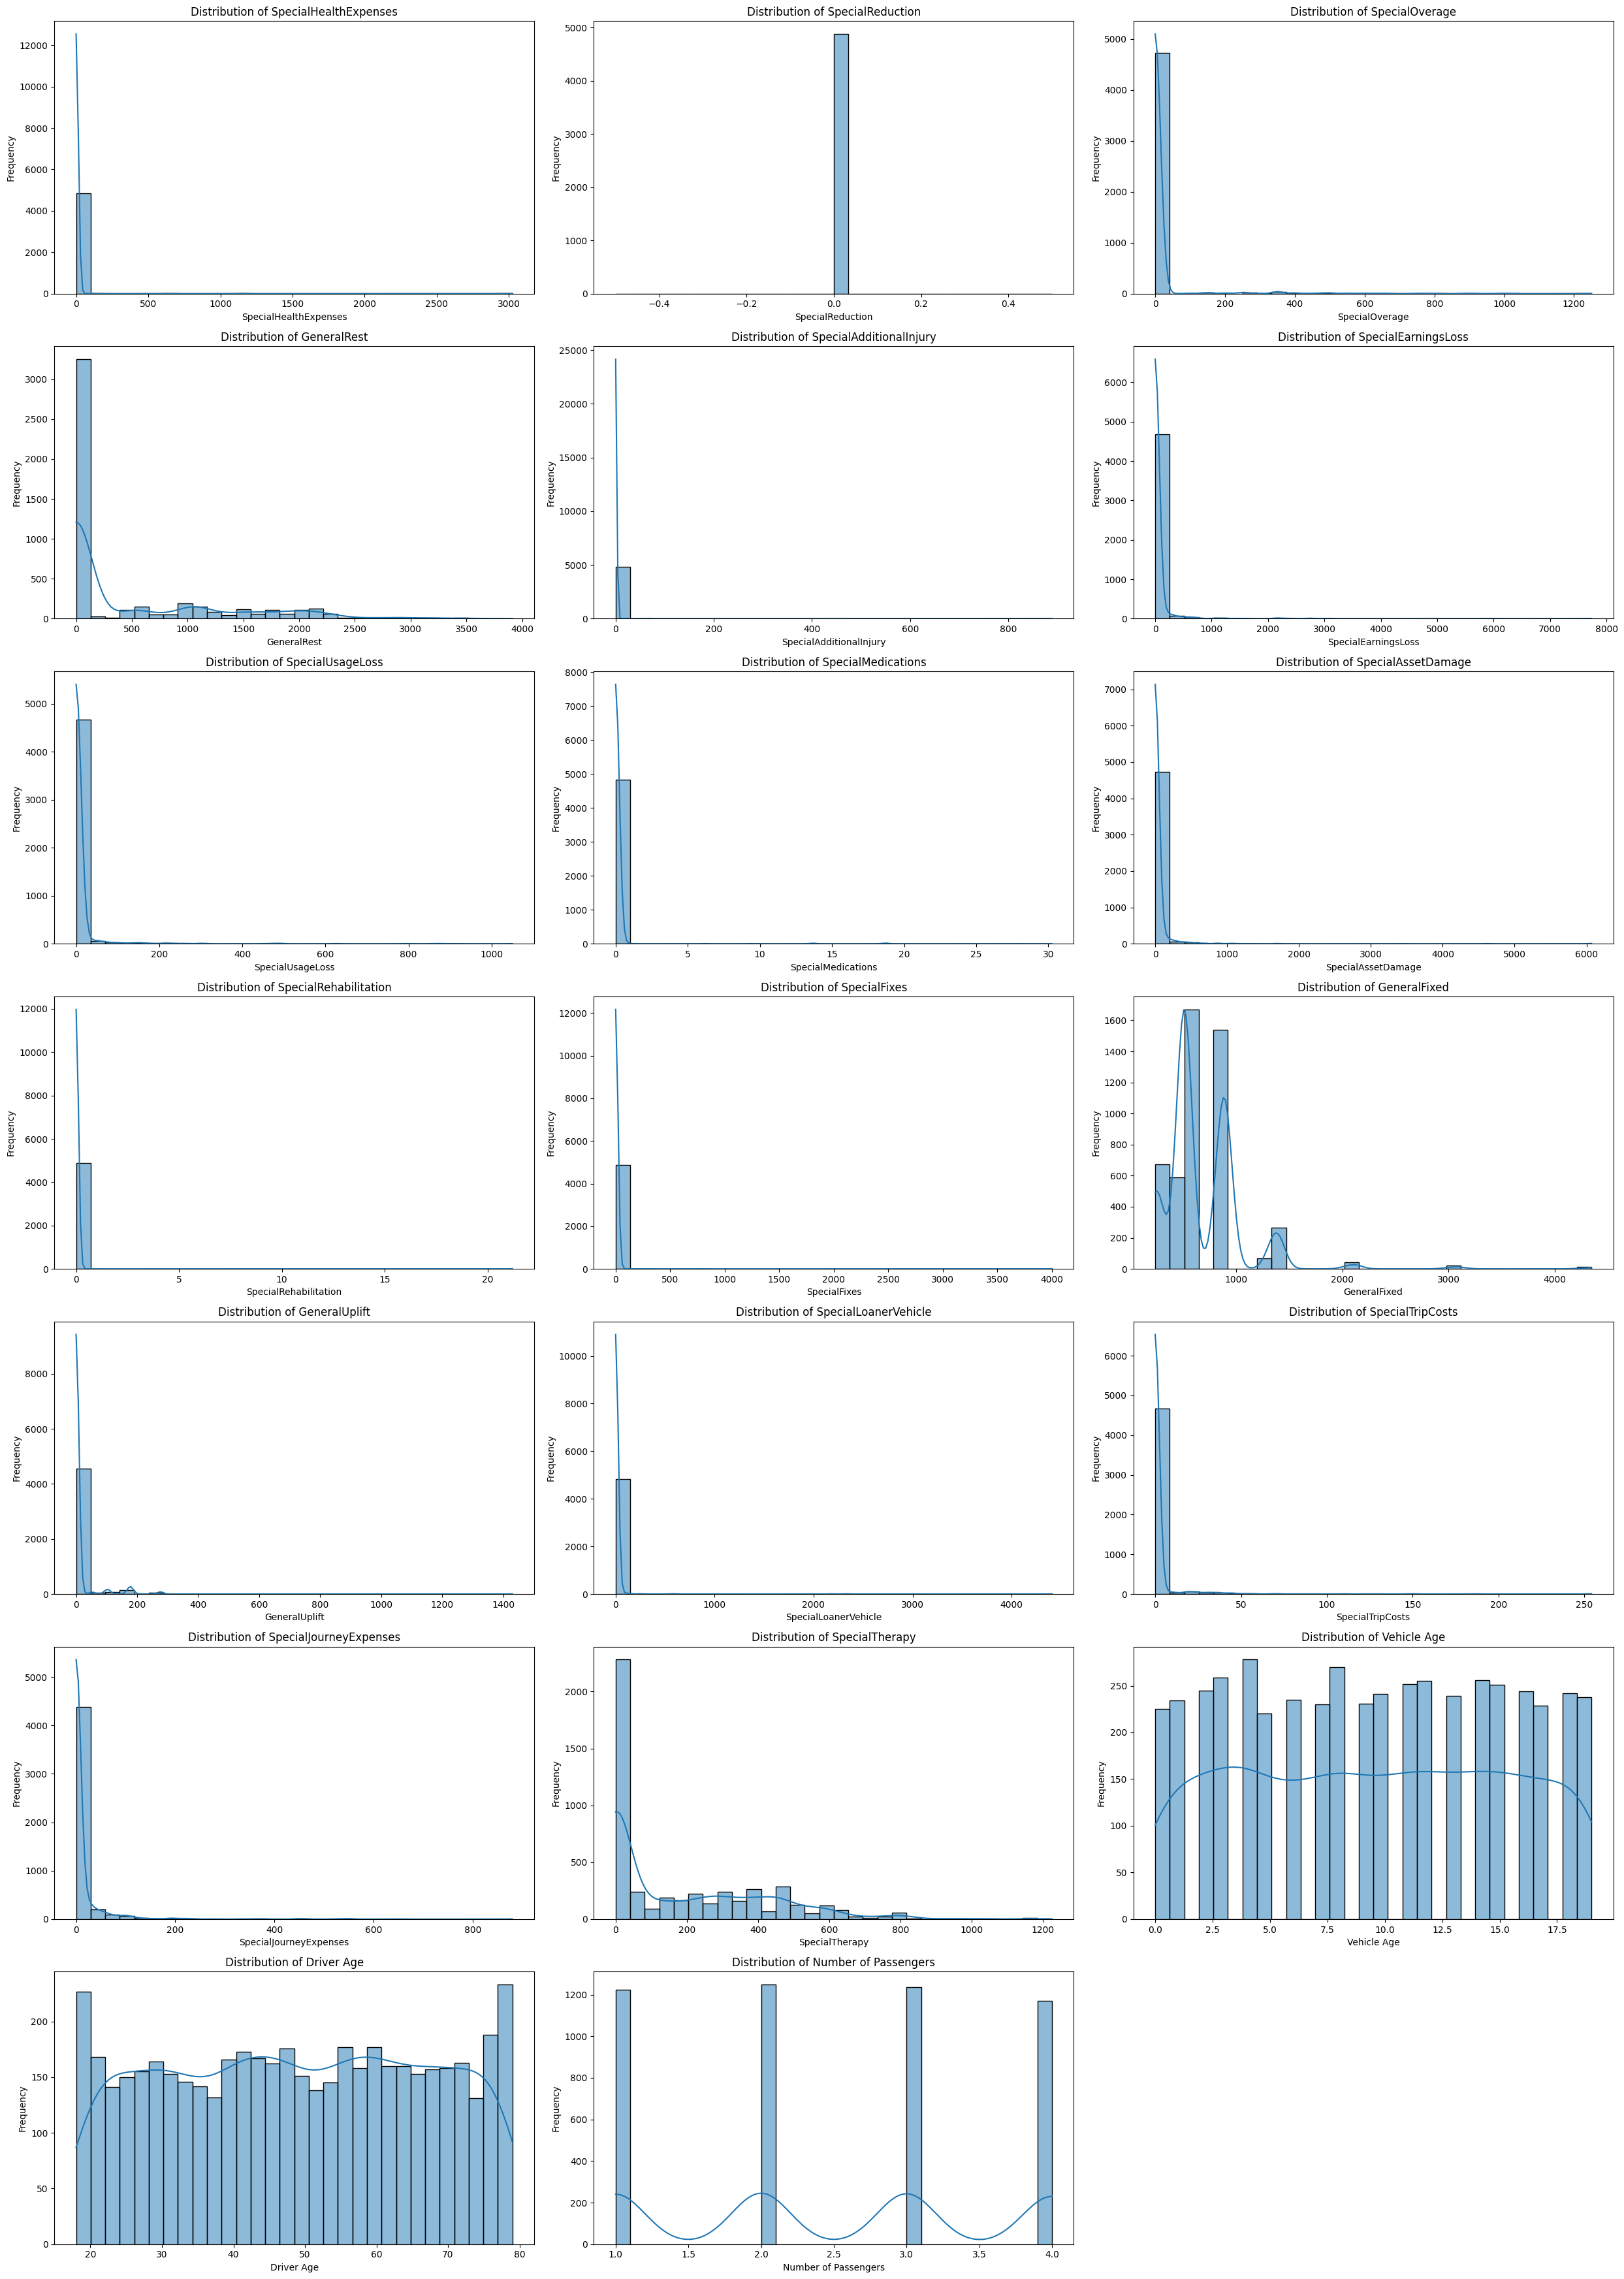

In [21]:
# visualize numerical input variables
numerical_data.drop('SettlementValue', axis=1, inplace=True) # drop the column of target variable

# Set up the figure and subplots
plt.figure(figsize=(25, 35))  # Adjust the figure size as needed
num_columns = len(numerical_data.columns)
rows = (num_columns // 3) + 1  # Adjust the number of rows based on the number of columns

# Loop through each numerical column and plot its distribution
for i, column in enumerate(numerical_data.columns, 1):
    plt.subplot(rows, 3, i)  # Create a subplot for each column
    sns.histplot(numerical_data[column], kde=True, bins=30)  # Plot histogram with KDE
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()

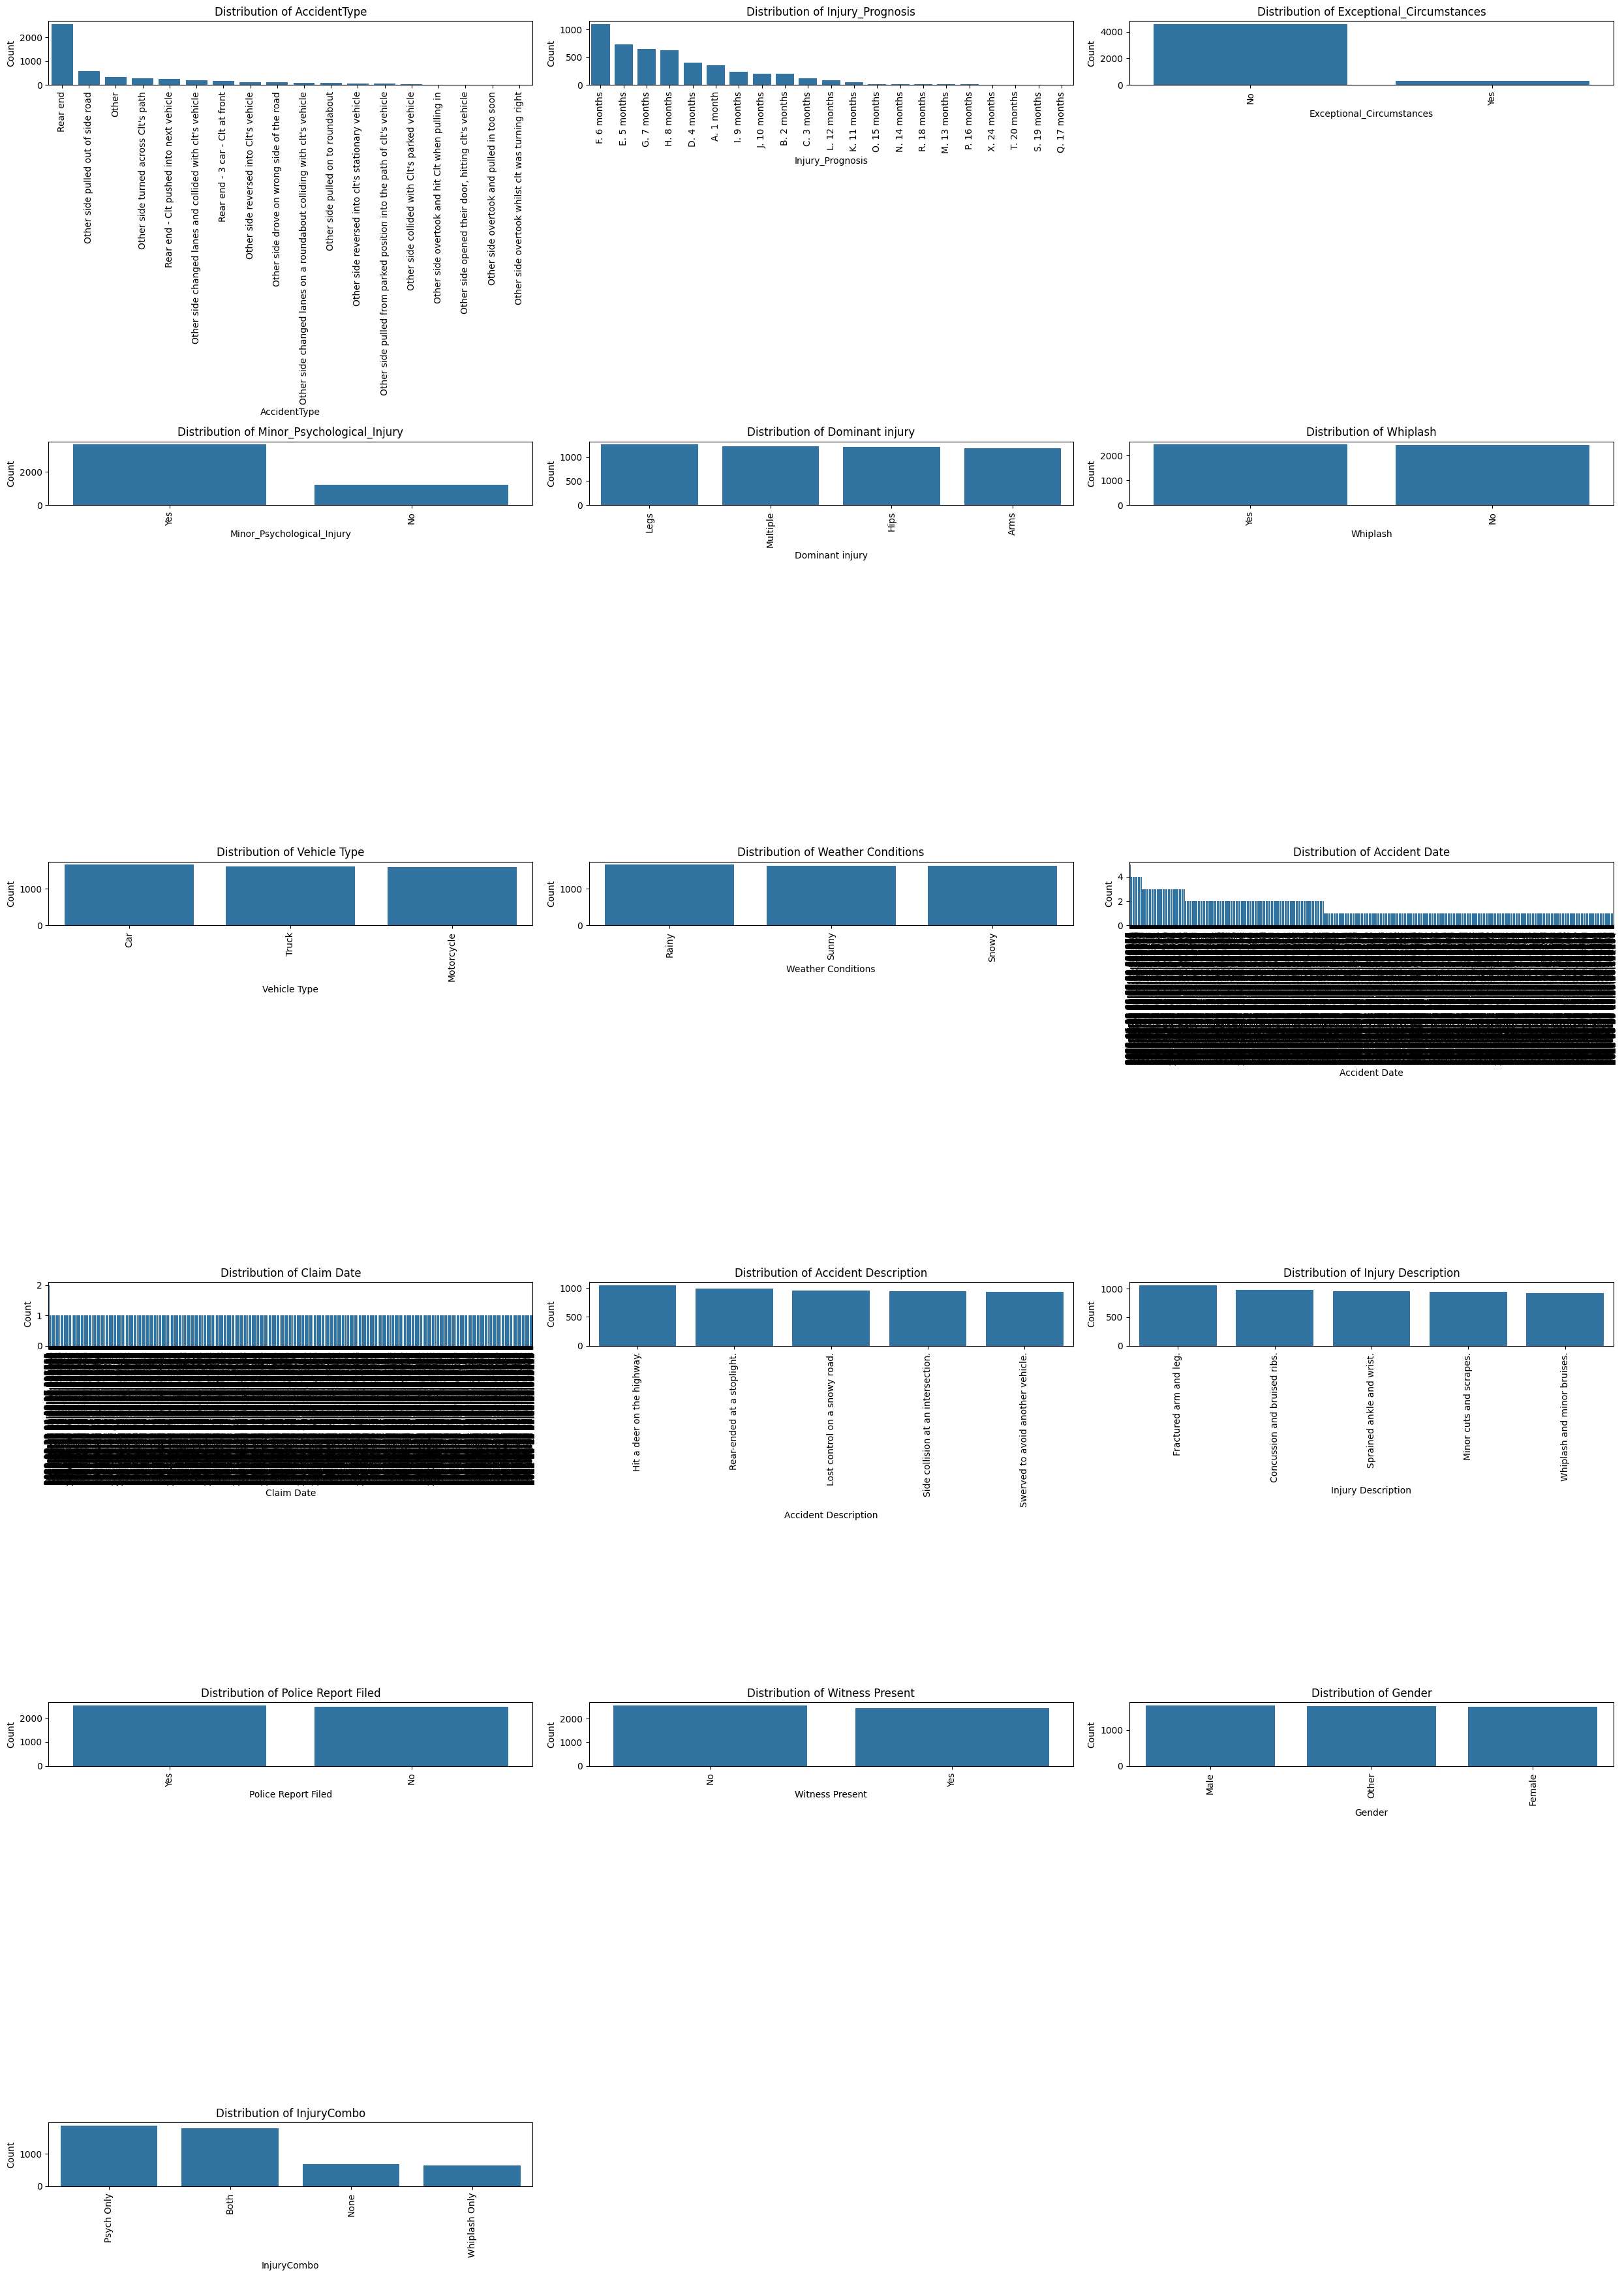

In [22]:
# visualize categorical input variables

plt.figure(figsize=(25, 35))  
num_columns = len(categorical_data.columns)
rows = (num_columns // 3) + 1  # Adjust the number of rows based on the number of columns

# Loop through each categorical column and plot its distribution
for i, column in enumerate(categorical_data.columns, 1):
    plt.subplot(rows, 3, i)  # Create a subplot for each column
    sns.countplot(x=categorical_data[column], order=categorical_data[column].value_counts().index)  # Plot bar plot
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=90)  # Rotate x-axis labels for better readability

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()


In [23]:
## Convert to Datetime format for better analysis
insurance_data['Claim Date'] = pd.to_datetime(insurance_data['Claim Date'])
insurance_data['Accident Date'] = pd.to_datetime(insurance_data['Accident Date'])

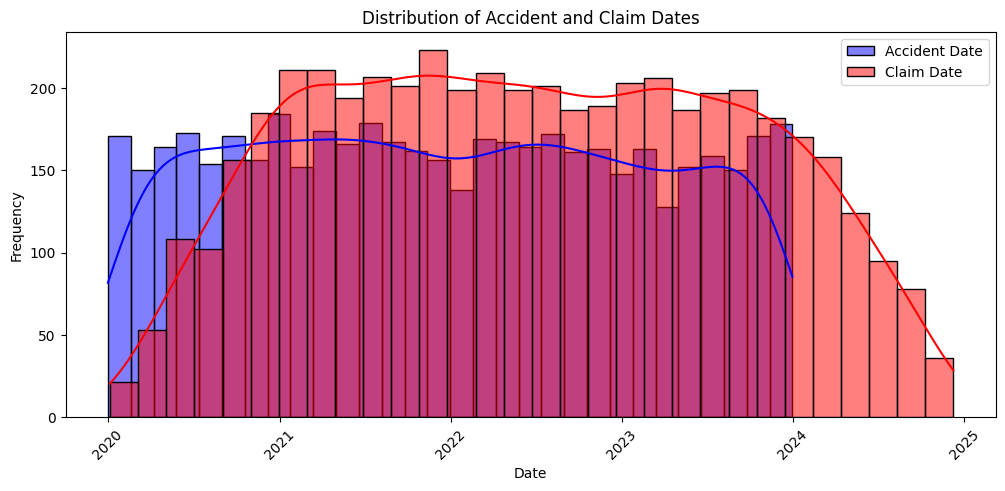

In [24]:
plt.figure(figsize=(12, 5))
sns.histplot(insurance_data["Accident Date"], bins=30, kde=True, color='blue', label="Accident Date")
sns.histplot(insurance_data["Claim Date"], bins=30, kde=True, color='red', label="Claim Date")

plt.xlabel("Date")
plt.ylabel("Frequency")
plt.title("Distribution of Accident and Claim Dates")
plt.legend()
plt.xticks(rotation=45)
plt.show()


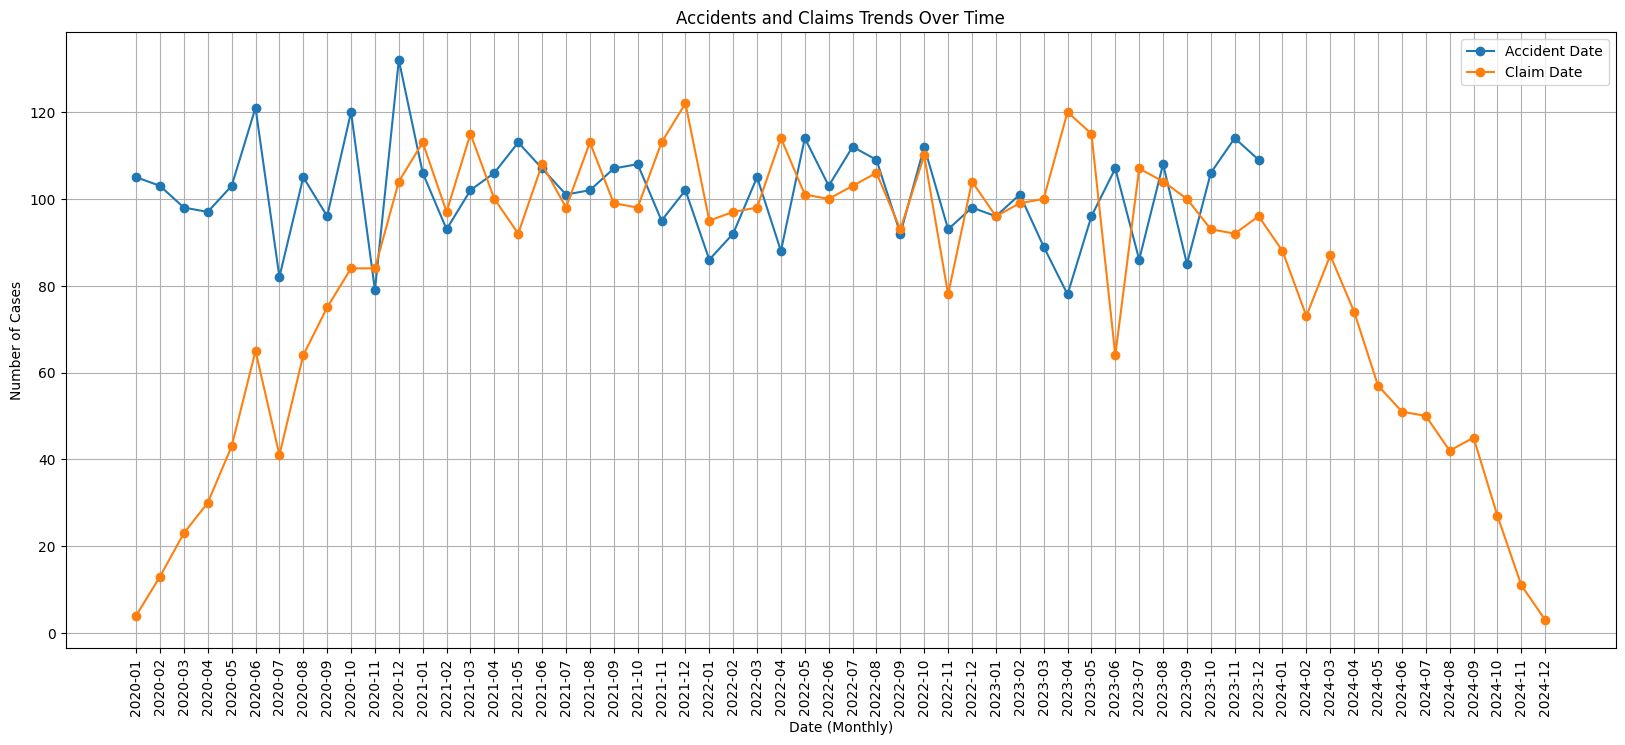

In [25]:
# visualization for date time data

# Count number of claims per month
accident = insurance_data.groupby(insurance_data["Accident Date"].dt.to_period("M")).size()
claim = insurance_data.groupby(insurance_data["Claim Date"].dt.to_period("M")).size()

# Plot
plt.figure(figsize=(20, 8))
plt.plot(accident.index.astype(str), accident, marker='o', label="Accident Date")
plt.plot(claim.index.astype(str), claim, marker='o', label="Claim Date")

plt.xlabel("Date (Monthly)")
plt.ylabel("Number of Cases")
plt.title("Accidents and Claims Trends Over Time")
plt.legend()
plt.xticks(rotation=90)
plt.grid()
plt.show()


Total number of accidents: 5000
Number of rear-end accidents: 2564


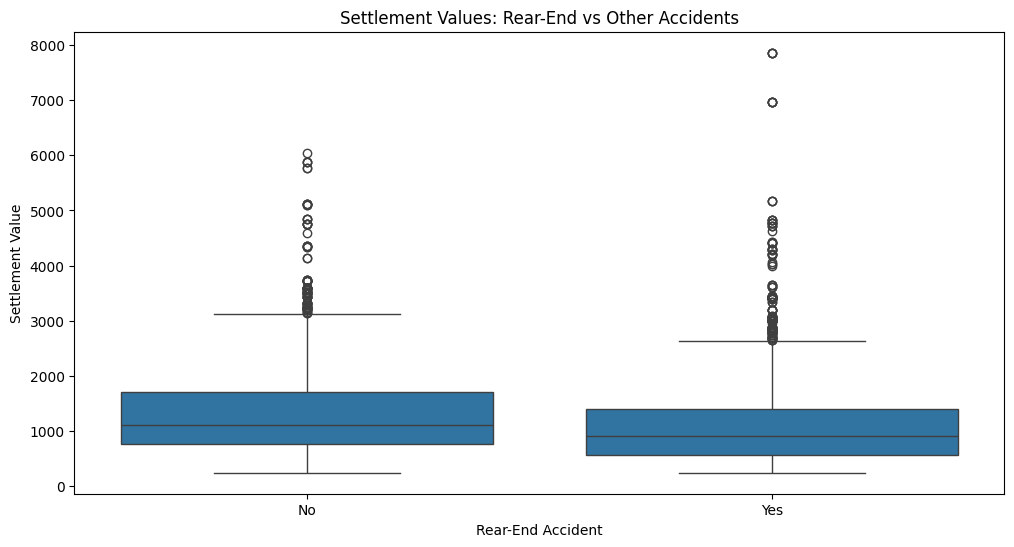


Settlement Value Summary for Rear-End Accidents:
count    2508.000000
mean     1118.227161
std       829.283683
min       240.000000
25%       566.110000
50%       895.000000
75%      1358.300000
max      7862.900000
Name: SettlementValue, dtype: float64


In [26]:
# Create a dataframe with only rear-end accidents
rear_end_accidents = insurance_data[insurance_data['AccidentType'] == 'Rear end']

# Display basic information about rear-end accidents
print(f"Total number of accidents: {len(insurance_data)}")
print(f"Number of rear-end accidents: {len(rear_end_accidents)}")

# Visualize settlement values for rear-end vs non-rear-end accidents
plt.figure(figsize=(12, 6))
sns.boxplot(x=insurance_data['AccidentType'].str.contains('Rear end'), 
            y=insurance_data['SettlementValue'])
plt.title('Settlement Values: Rear-End vs Other Accidents')
plt.xlabel('Rear-End Accident')
plt.xticks([0, 1], ['No', 'Yes'])
plt.ylabel('Settlement Value')
plt.show()

# Summary statistics of rear-end accidents
rear_end_summary = rear_end_accidents['SettlementValue'].describe()
print("\nSettlement Value Summary for Rear-End Accidents:")
print(rear_end_summary)

Total number of accidents: 5000
Number of non-rear-end accidents: 2030
Percentage of non-rear-end accidents: 40.60%

Settlement Value Summary by Non-Rear-End Accident Type:
                                                    count         mean  \
AccidentType                                                             
Other side pulled out of side road                    561  1426.404242   
Other                                                 337  1346.378131   
Other side turned across Clt's path                   266  1373.473910   
Other side changed lanes and collided with clt'...    185  1343.563189   
Other side reversed into Clt's vehicle                 99  1120.521414   
Other side drove on wrong side of the road             98  1457.158265   
Other side changed lanes on a roundabout collid...     82  1253.673171   
Other side pulled on to roundabout                     79  1388.966582   
Other side reversed into clt's stationary vehicle      62   805.546452   
Other side pu

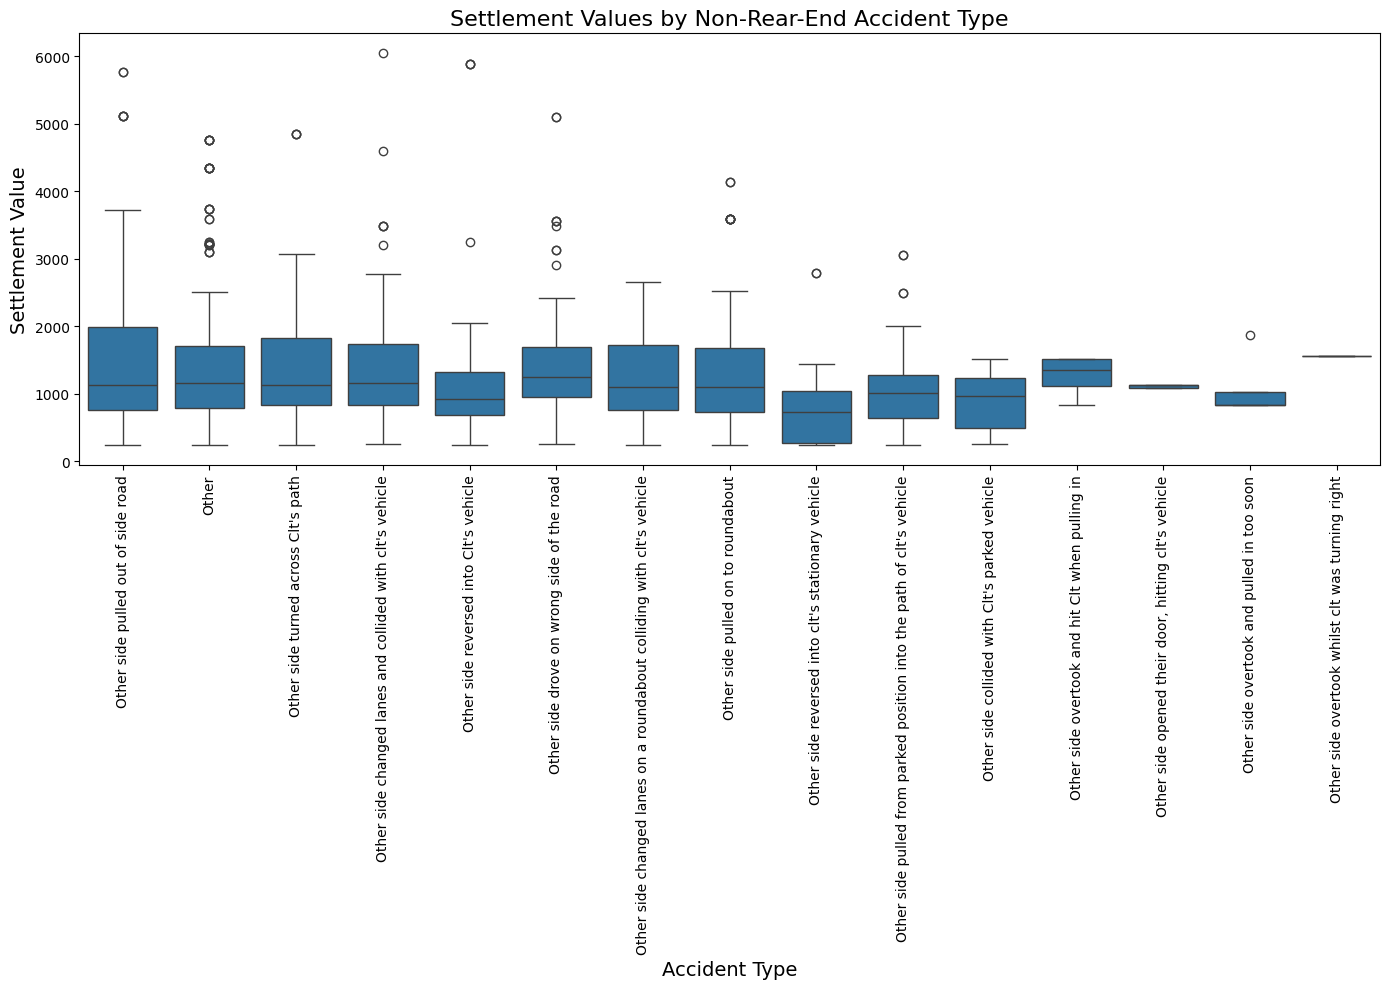

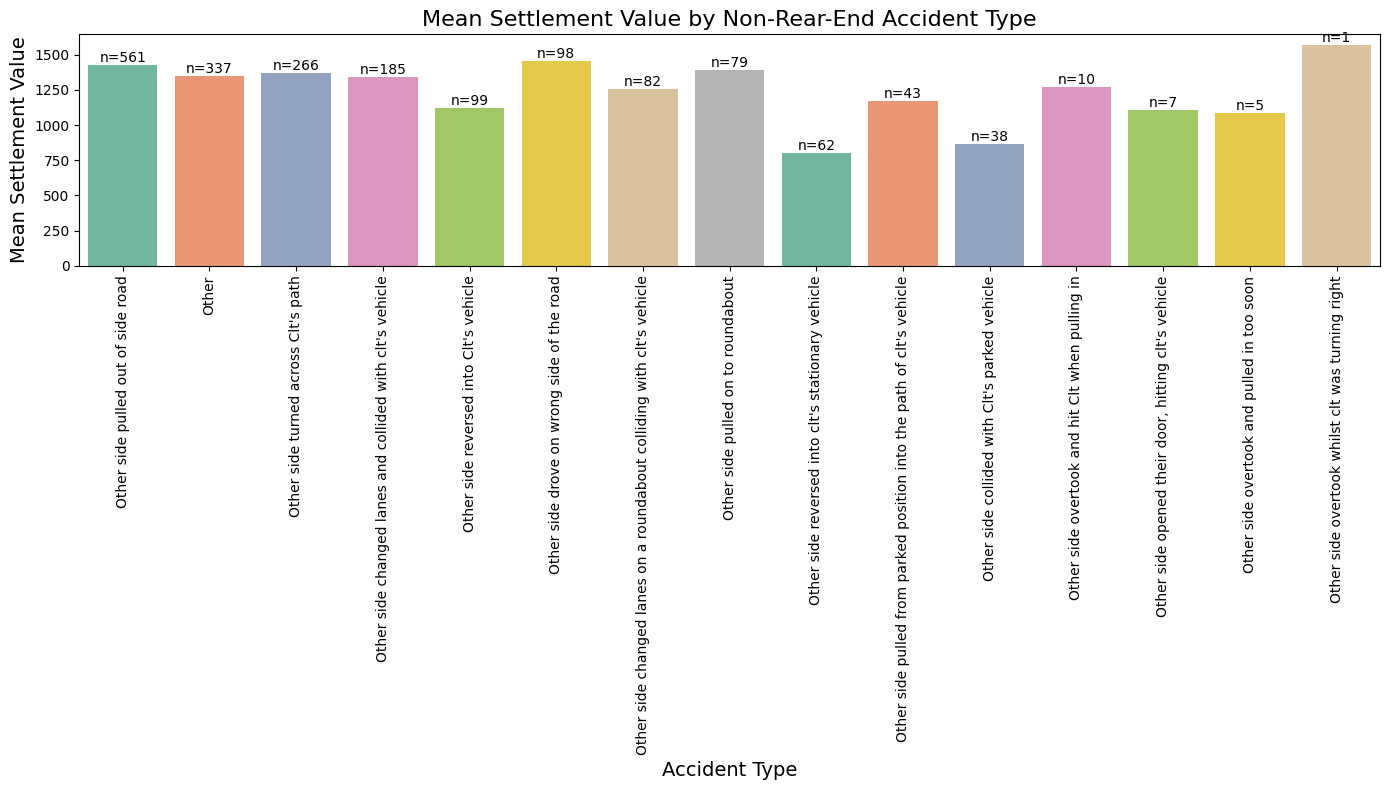

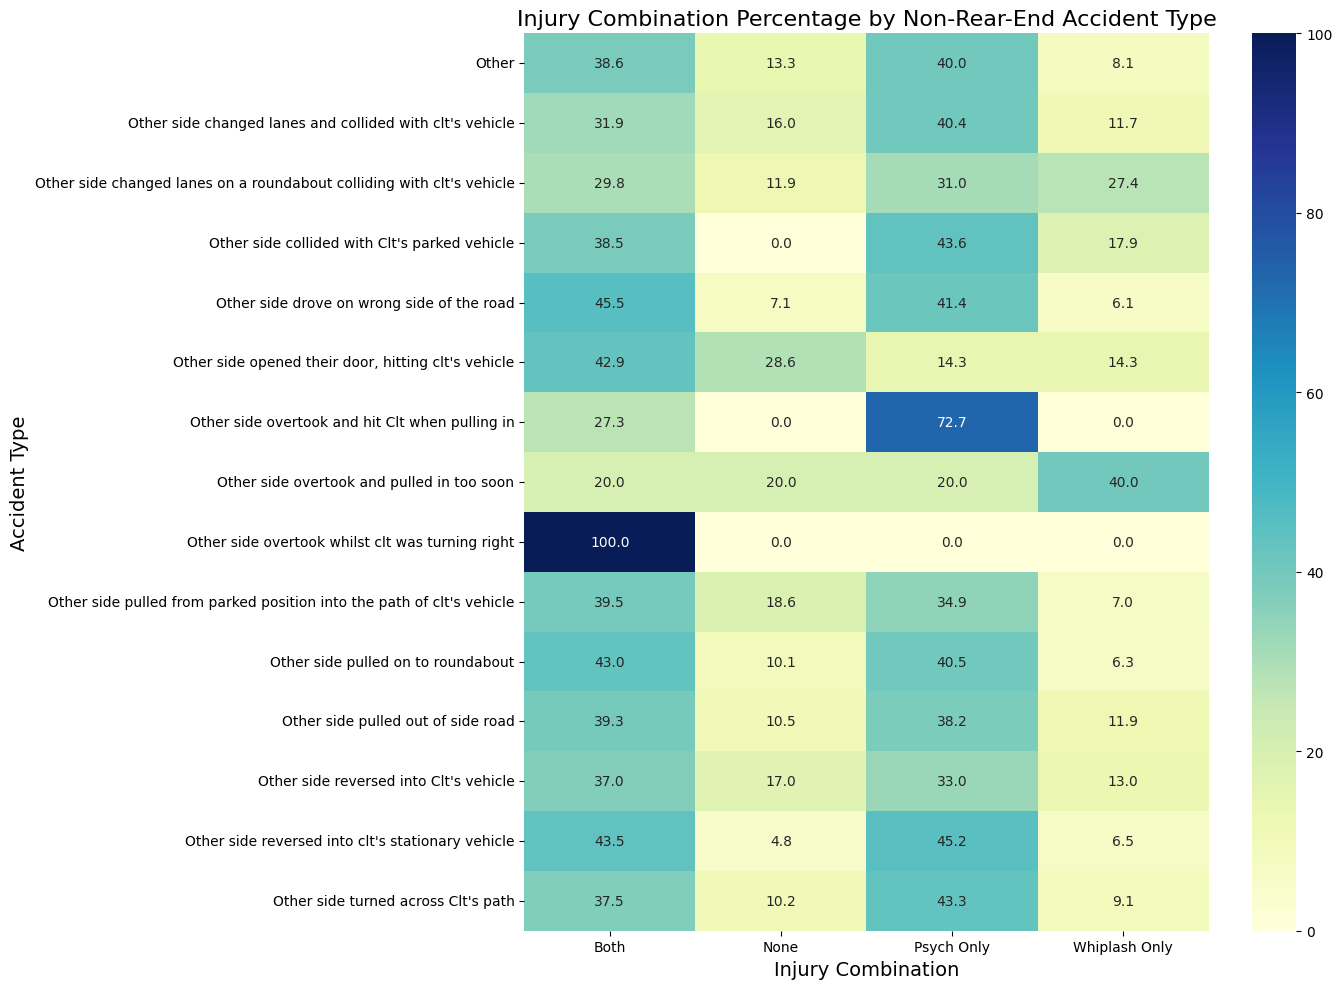

In [27]:
# Create a dataframe with only non-rear-end accidents
non_rear_end_accidents = insurance_data[~insurance_data['AccidentType'].str.contains('Rear end', na=False)]

# Display basic information about non-rear-end accidents
print(f"Total number of accidents: {len(insurance_data)}")
print(f"Number of non-rear-end accidents: {len(non_rear_end_accidents)}")
print(f"Percentage of non-rear-end accidents: {len(non_rear_end_accidents) / len(insurance_data) * 100:.2f}%")

# Group by accident type and calculate summary statistics
accident_type_summary = non_rear_end_accidents.groupby('AccidentType')['SettlementValue'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).sort_values('count', ascending=False)
print("\nSettlement Value Summary by Non-Rear-End Accident Type:")
print(accident_type_summary)

# Visualize settlement values by accident type
plt.figure(figsize=(14, 10))
sns.boxplot(data=non_rear_end_accidents, x='AccidentType', y='SettlementValue', order=accident_type_summary.index)
plt.title('Settlement Values by Non-Rear-End Accident Type', fontsize=16)
plt.xlabel('Accident Type', fontsize=14)
plt.ylabel('Settlement Value', fontsize=14)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Create a bar chart for mean settlement values by accident type
plt.figure(figsize=(14, 8))
sns.barplot(x=accident_type_summary.index, y=accident_type_summary['mean'], hue=accident_type_summary.index, palette='Set2')
plt.title('Mean Settlement Value by Non-Rear-End Accident Type', fontsize=16)
plt.xlabel('Accident Type', fontsize=14)
plt.ylabel('Mean Settlement Value', fontsize=14)
plt.xticks(rotation=90)
# Add count labels on top of each bar
for i, (_, row) in enumerate(accident_type_summary.iterrows()):
    plt.text(i, row['mean'], f"n={int(row['count'])}", ha='center', va='bottom')
plt.tight_layout()
plt.show()

# Compare injury combinations by accident type
injury_combo_counts = pd.crosstab(
    non_rear_end_accidents['AccidentType'], 
    non_rear_end_accidents['InjuryCombo']
)
injury_percentages = injury_combo_counts.div(injury_combo_counts.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 10))
sns.heatmap(injury_percentages, annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('Injury Combination Percentage by Non-Rear-End Accident Type', fontsize=16)
plt.ylabel('Accident Type', fontsize=14)
plt.xlabel('Injury Combination', fontsize=14)
plt.tight_layout()
plt.show()

95th percentile of Settlement Value: $2854.81
Number of claims above 95th percentile: 243 (4.86%)

Summary of high-value claims:
count     243.000000
mean     3833.242140
std      1055.252028
min      2858.970000
25%      3110.000000
50%      3428.000000
75%      4294.640000
max      7862.900000
Name: SettlementValue, dtype: float64


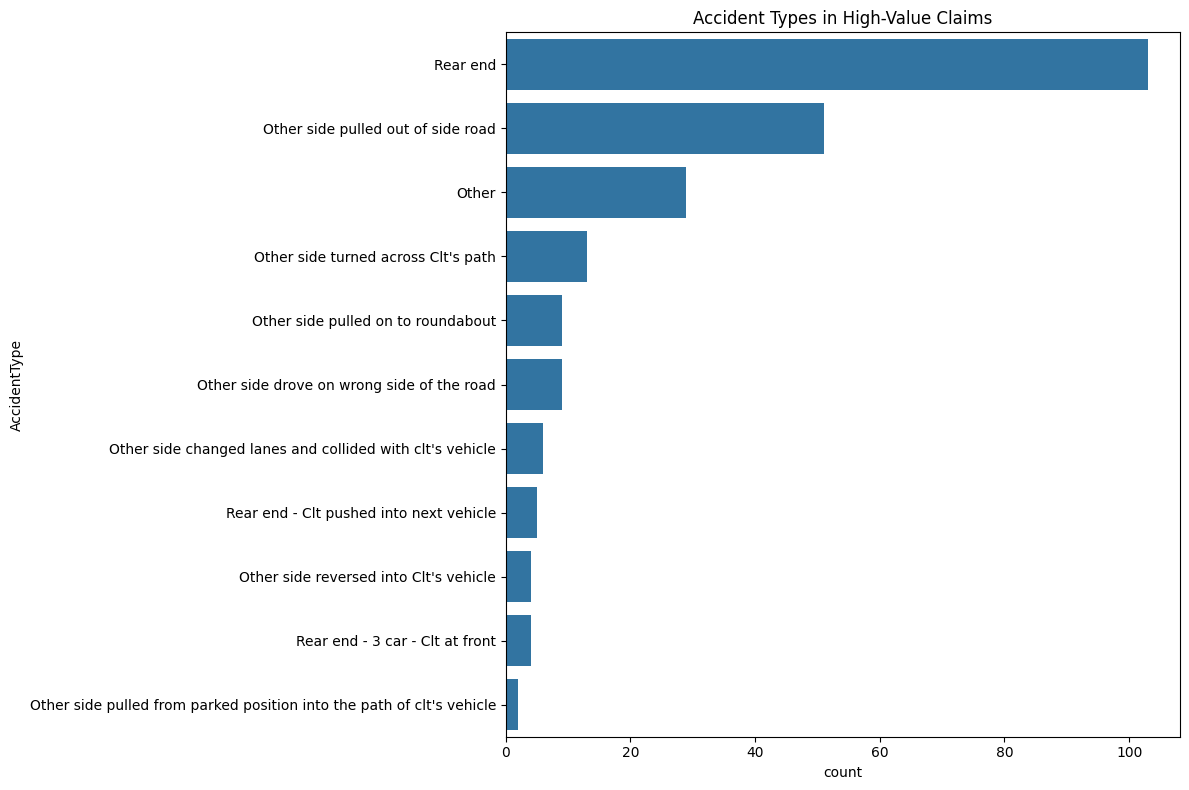

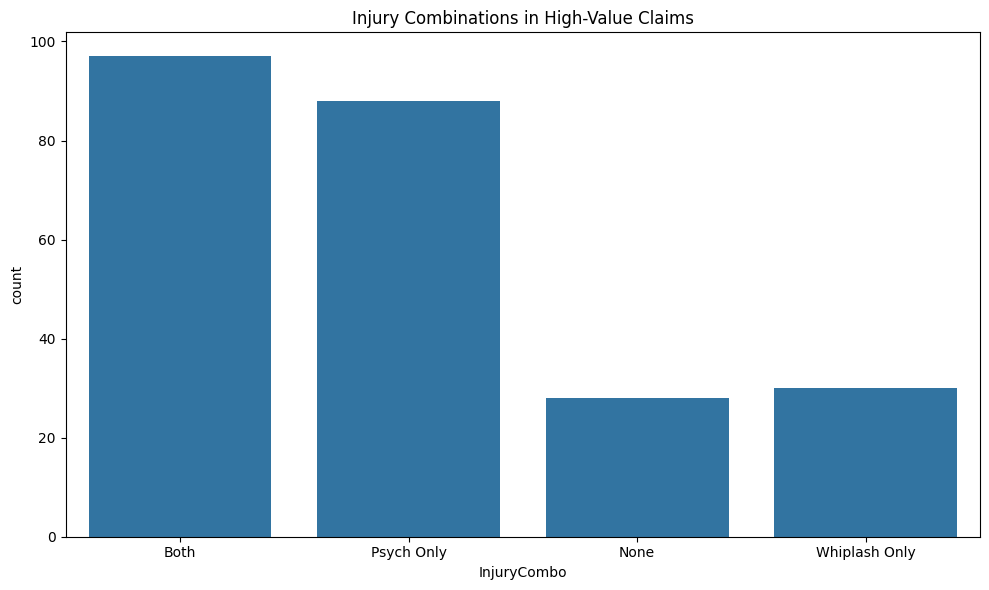

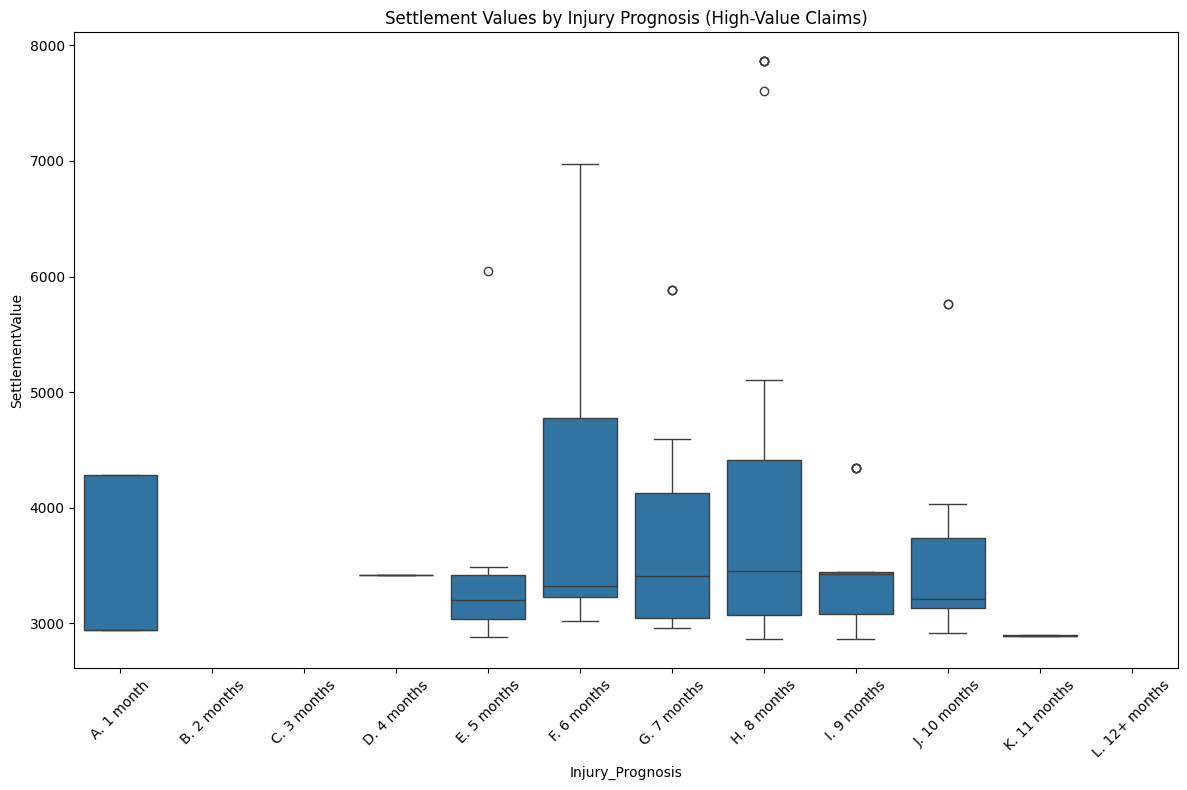

In [28]:
# Calculate the 95th percentile of SettlementValue
percentile_95 = np.percentile(insurance_data['SettlementValue'].dropna(), 95)

# Filter the dataframe to get records where SettlementValue is greater than the 95th percentile
high_value_claims = insurance_data[insurance_data['SettlementValue'] > percentile_95]

# Print basic information
print(f"95th percentile of Settlement Value: ${percentile_95:.2f}")
print(f"Number of claims above 95th percentile: {len(high_value_claims)} ({len(high_value_claims)/len(insurance_data)*100:.2f}%)")

# Analyze the characteristics of high-value claims
print("\nSummary of high-value claims:")
print(high_value_claims['SettlementValue'].describe())

# Distribution of accident types for high-value claims
plt.figure(figsize=(12, 8))
sns.countplot(data=high_value_claims, y='AccidentType', order=high_value_claims['AccidentType'].value_counts().index)
plt.title('Accident Types in High-Value Claims')
plt.tight_layout()
plt.show()

# Distribution of injury combinations for high-value claims
plt.figure(figsize=(10, 6))
sns.countplot(data=high_value_claims, x='InjuryCombo')
plt.title('Injury Combinations in High-Value Claims')
plt.tight_layout()
plt.show()

# Relationship between injury prognosis and settlement value
plt.figure(figsize=(12, 8))
sns.boxplot(data=high_value_claims, x='Injury_Prognosis', y='SettlementValue', order=['A. 1 month', 'B. 2 months', 'C. 3 months', 
                                                                                       'D. 4 months', 'E. 5 months', 'F. 6 months', 
                                                                                       'G. 7 months', 'H. 8 months', 'I. 9 months', 
                                                                                       'J. 10 months', 'K. 11 months', 'L. 12+ months'])
plt.title('Settlement Values by Injury Prognosis (High-Value Claims)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Number of high-value claims: 243 (4.86% of total)


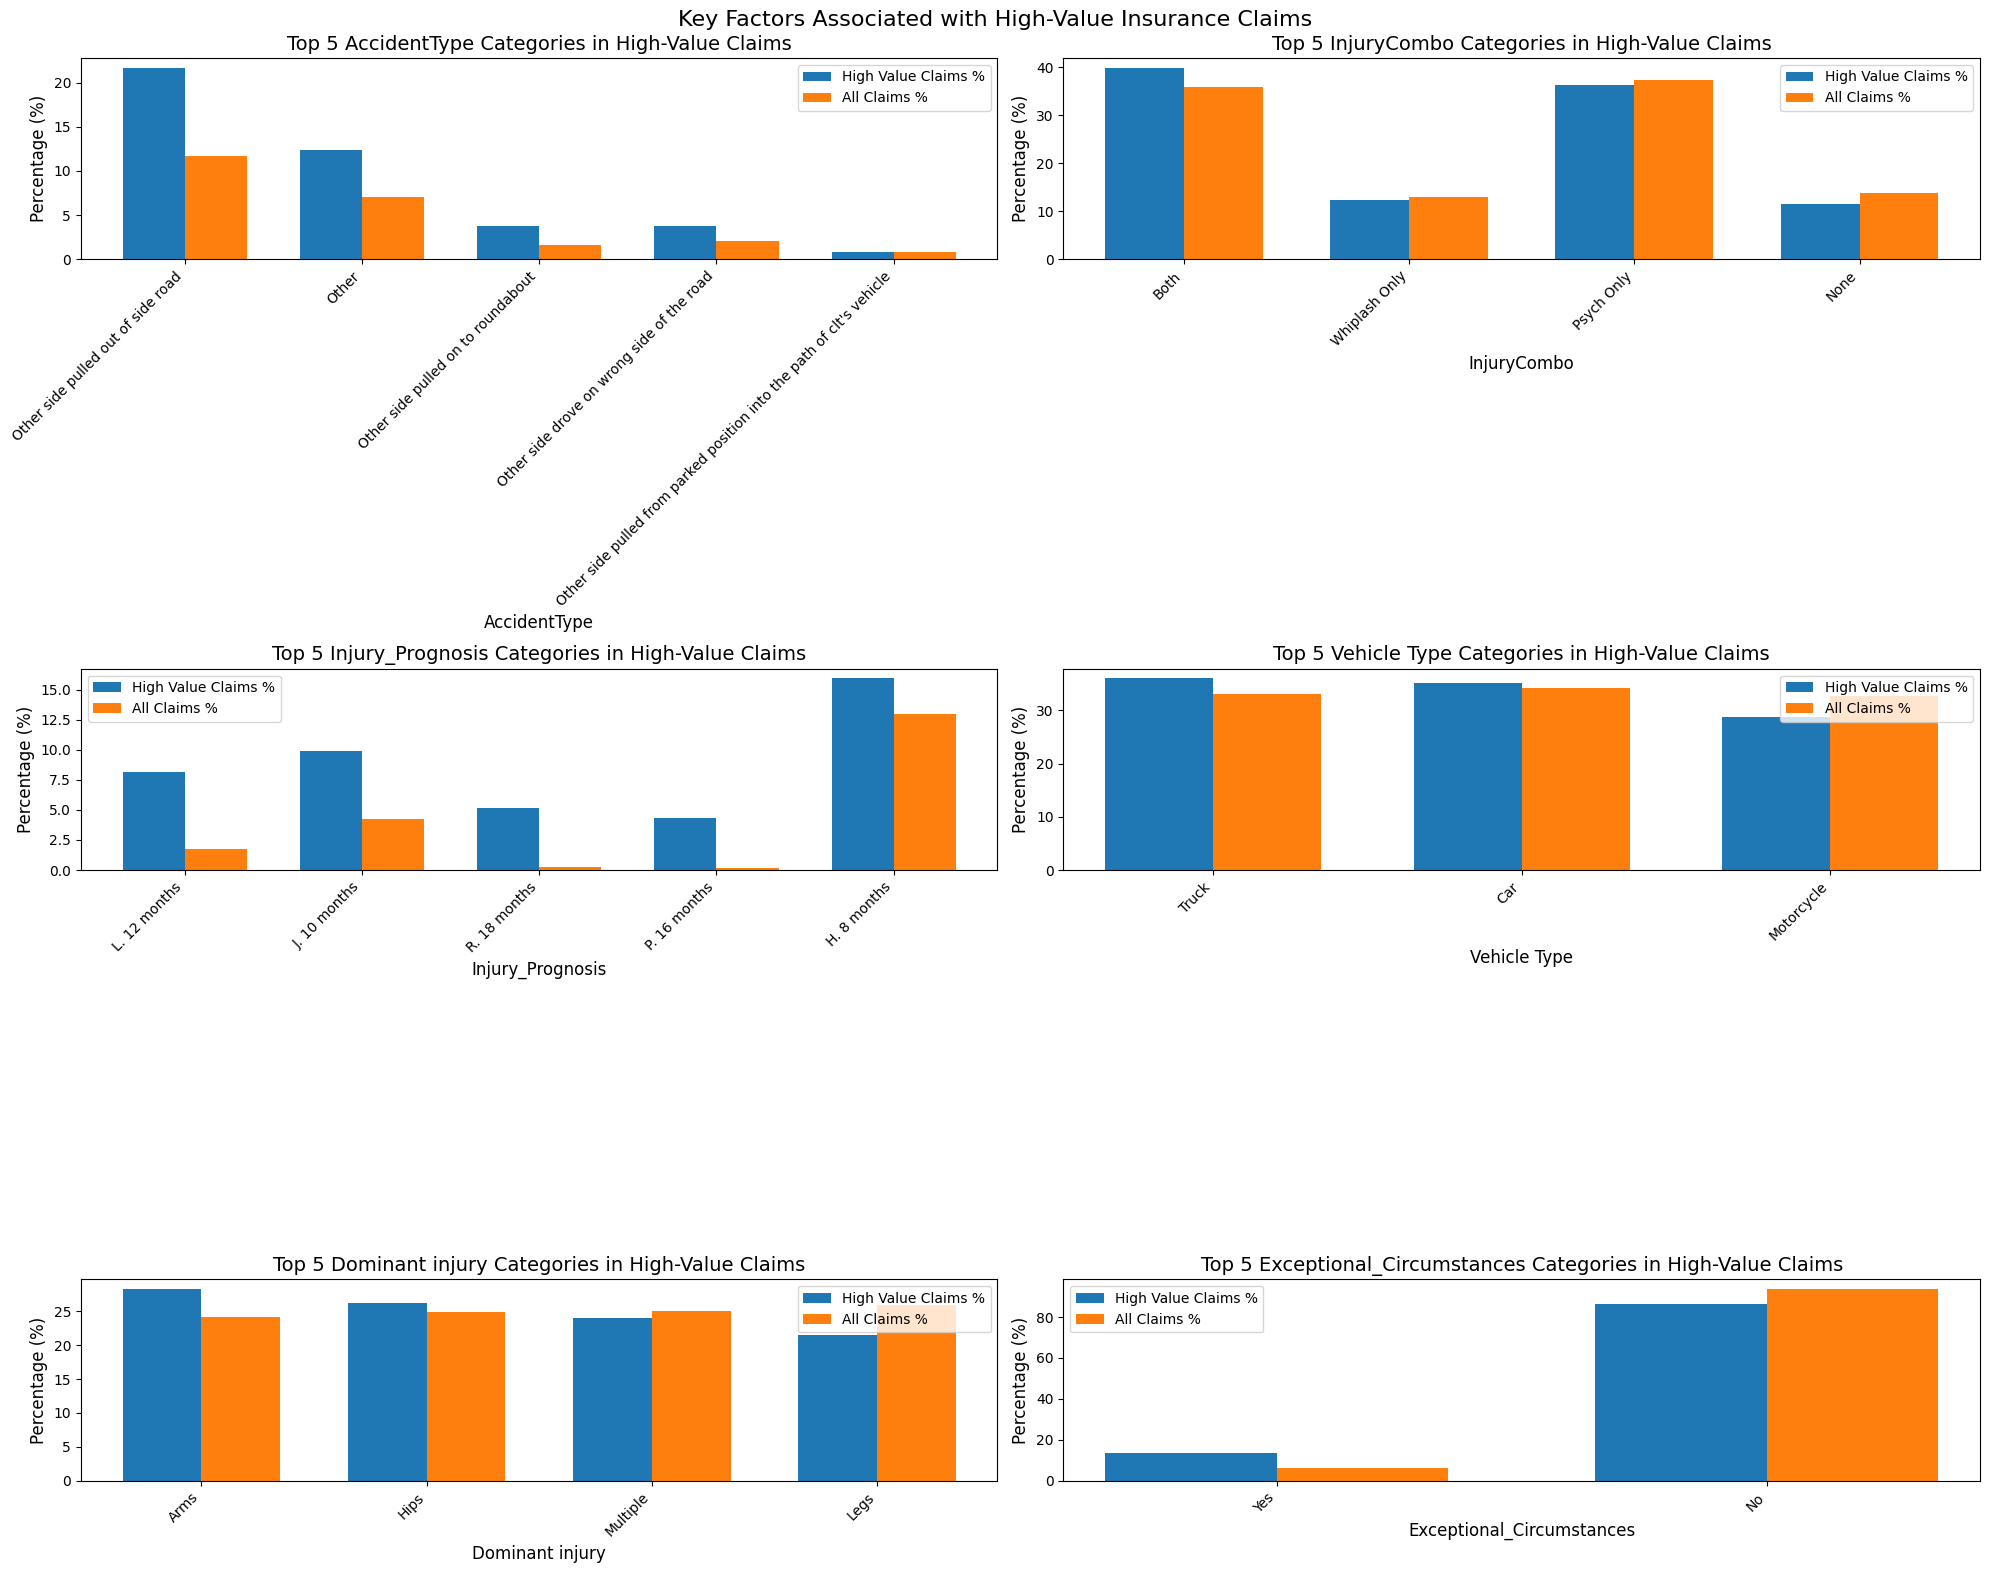


Correlation with Settlement Value:
SettlementValue       1.000000
GeneralRest           0.576297
GeneralFixed          0.534009
SpecialTherapy        0.317249
SpecialAssetDamage    0.270252
Driver Age            0.017975
Vehicle Age          -0.013916
Name: SettlementValue, dtype: float64


In [29]:
# Analyze claims with settlement values above the 95th percentile
print(f"Number of high-value claims: {len(high_value_claims)} ({len(high_value_claims)/len(insurance_data)*100:.2f}% of total)")

# Create a function to compare frequency of characteristics in high-value vs all claims
def compare_feature_distribution(feature):
    # Calculate distribution in high-value claims
    high_value_dist = high_value_claims[feature].value_counts(normalize=True) * 100
    # Calculate distribution in all claims
    all_dist = insurance_data[feature].value_counts(normalize=True) * 100
    # Calculate the difference (overrepresentation)
    diff = high_value_dist - all_dist.reindex(high_value_dist.index).fillna(0)
    
    # Create a DataFrame for comparison
    comparison = pd.DataFrame({
        'High Value %': high_value_dist,
        'All Claims %': all_dist.reindex(high_value_dist.index).fillna(0),
        'Difference': diff
    }).sort_values('Difference', ascending=False)
    
    return comparison

# Analyze categorical features with most significant impact
features_to_analyze = ['AccidentType', 'InjuryCombo', 'Injury_Prognosis', 
                       'Vehicle Type', 'Dominant injury', 'Exceptional_Circumstances']

# Create visualizations to compare distributions
plt.figure(figsize=(20, 16))
for i, feature in enumerate(features_to_analyze, 1):
    plt.subplot(3, 2, i)
    comparison = compare_feature_distribution(feature)
    
    # Plot top 5 categories with highest difference
    top_categories = comparison.head(5).index
    
    # Extract data for plotting
    high_val_pct = comparison.loc[top_categories, 'High Value %']
    all_pct = comparison.loc[top_categories, 'All Claims %']
    
    # Create bar positions
    x = np.arange(len(top_categories))
    width = 0.35
    
    # Create grouped bars
    plt.bar(x - width/2, high_val_pct, width, label='High Value Claims %')
    plt.bar(x + width/2, all_pct, width, label='All Claims %')
    
    plt.title(f'Top 5 {feature} Categories in High-Value Claims', fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.xticks(x, top_categories, rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()

plt.subplots_adjust(hspace=0.4)
plt.suptitle('Key Factors Associated with High-Value Insurance Claims', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

# Correlation between numeric features and settlement value
numeric_cols = ['SpecialAssetDamage', 'GeneralRest', 'SpecialTherapy', 
                'GeneralFixed', 'Driver Age', 'Vehicle Age']
correlation = insurance_data[numeric_cols + ['SettlementValue']].corr()['SettlementValue'].sort_values(ascending=False)
print("\nCorrelation with Settlement Value:")
print(correlation)

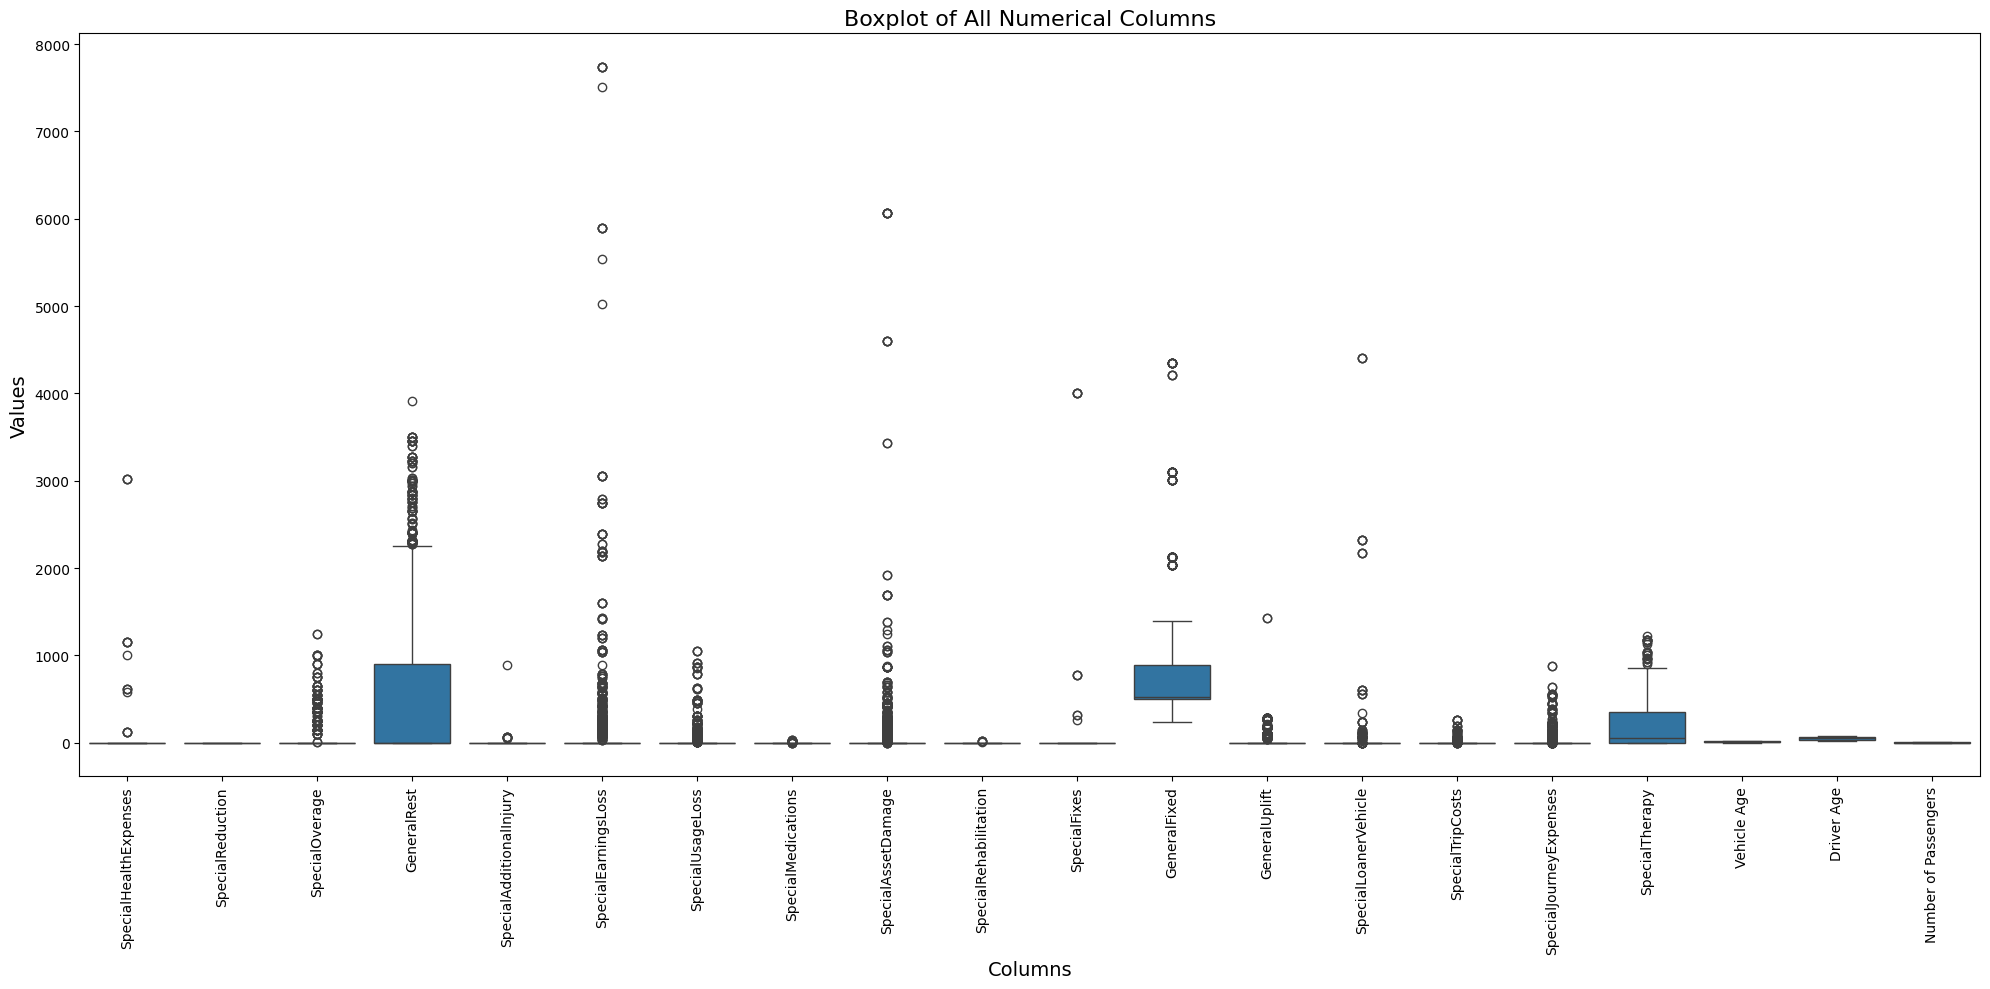

In [30]:
# visualize using boxplot

# Melt the DataFrame to long format for Seaborn
melted_data = numerical_data.melt(var_name='Columns', value_name='Values')

# Set up the figure
plt.figure(figsize=(20, 10))  # Adjust figure size for better readability

# Create a boxplot for all numerical columns
sns.boxplot(x='Columns', y='Values', data=melted_data)
plt.title('Boxplot of All Numerical Columns', fontsize=16)
plt.xlabel('Columns', fontsize=14)
plt.ylabel('Values', fontsize=14)
plt.xticks(rotation=90)  # Rotate x-axis labels vertically for better readability
plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()